# News trading model

Load the complete `public.article_insights` table from the local PostgreSQL database.

# 0. Environment Setup

In [16]:
%pip install pandas sqlalchemy "psycopg[binary]" torch transformers torcha
%pip install -q peft accelerate datasets
%pip install -U "torchao>=0.16.0"

import torch
from types import SimpleNamespace

###############################################################
## Data Preparation
################################################################

# If set to true, the train/validation/test split will be fixed and not random. This is useful for reproducibility.
FIXED_SPLIT = True

# Remove tickers from article insights
#   none - do not remove tickers
#   primary - remove only primary ticker
#   all - remove all tickers
REMOVE_TICKERS = "none"  # Options: "none", "primary", "all"

# Map of the sentiment
SENTIMENT_MAP = {
    1: "Strongly negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Strongly positive",
}
###############################################################
## Data Features
################################################################

# The column which contains the text that is the input for the model for
# predicting / extracting the sentiment
TEXT_COLUMN = "consolidated_insights"

# The column that contains the coded sentiment stemming from the text,
# used for training purposes only.
# 0=Unknown, 1=Strongly negative, 2=negative, 3=neutral, 4=positive, 5=Strongly positive
SENTIMENT_COLUMN = "sentiment"

# The column which is used to separate training, test and validation sets.
# The values in this column must be one of "training", "validation" or "test".
# Used only if FIXED_SPLIT is True. If FIXED_SPLIT is False, this column is ignored and the split is random.
SPLIT_COLUMN = "model_set"

# Column we want to predict: primary ticker price at +90 minutes ÷ price at article time − 1
TARGET_COLUMN = "gain_90m_after_article_first"

# The columns to be used as feature for model training. These columns must be present in the articles dataframe.
FEATURE_COLUMNS = [
    # Publishing outlet — some sources may be more market-moving than others
    "publisher",

    # --- Market state up to and including T (all safe: computed using only data at/before article time) ---

    # VIXY price at T vs... (volatility level at article time)
    "vix_at_article_time",

    # Target ticker's own price move from 09:30 open up to T (pre-article momentum)
    "intraday_gain_till_article_first",

    # AI-sector ETF (AIQ) move from open up to T (sector-wide)
    "aiq_ai_etf_intraday_gain_till_article",

    # --- Market state up to T-30 (pre-news baseline, for isolating the news effect) ---

    # Target ticker at T-30 vs 09:30 open
    "intraday_gain_till_30m_before_article_first",

    # AIQ at T-30 vs its open (sector control, pre-news)
    "aiq_ai_etf_intraday_gain_till_30m_before_article",

    # VIXY at T-30 vs its open (volatility control, pre-news)
    "vix_intraday_gain_till_30m_before_article_first",

    # T-30 -> T: price drift already underway right before pu
    # (safe: ends at T, does not touch the T+90 target window)
    "intraday_gain_30m_before_till_article_first",
]

assert TARGET_COLUMN not in FEATURE_COLUMNS, (
    f"Target column {TARGET_COLUMN!r} must not appear in FEATURE_COLUMNS."
)

# Map for displaying human-friendly titles
FEATURE_NAME_MAP = {
    "vix_at_article_time": "Vix",
    "intraday_gain_till_article_first": "Stock (Intraday Gain till Article)",
    "aiq_ai_etf_intraday_gain_till_article": "AI Index (Intraday Gain till Article)",
    # Add other mappings if desired, otherwise original column names will be used
}

################################################################
# Find the best device available: CUDA, MPS (Apple Silicon), or CPU
################################################################
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
if torch.backends.mps.is_available():
    DEVICE = "mps"
device = torch.device(DEVICE)
print(f"Using device: {device}")

################################################################
# Find the best device available: CUDA, MPS (Apple Silicon), or CPU
################################################################
DATA_SOURCE = "online_csv" # either online_csv or local_postgres

#################################################################
## model-specific hyperparameters
#################################################################

ENC_NN_SEPARATE = SimpleNamespace(
  MAX_LENGTH = 256,
  MODEL_NAME = "distilbert-base-uncased", # base model to use for tokenization & encoder
  TOKENIZATION_BATCH_SIZE = 128,
  ENCODER_TRAIN_BATCH_SIZE = 16,
  ENCODER_TRAIN_LEARNING_RATE = 1e-5,
  ENCODER_TRAIN_WEIGHT_DECAY = 0.01,
  ENCODER_TRAIN_EPOCHS = 10,
  FUSION_TRAIN_LEARNING_RATE = 1e-4,
  FUSION_TRAIN_WEIGHT_DECAY = 0.01,
  FUSION_TRAIN_BATCH_SIZE = 64,
  FUSION_TRAIN_EPOCHS = 100,
)

ENC_NN_COMBINED = SimpleNamespace(
  MAX_LENGTH = 256,
  MODEL_NAME = "distilbert-base-uncased",
  TRAIN_EPOCHS = 10,
  TRAIN_LEARNING_RATE = 1e-4,
  TRAIN_WEIGHT_DECAY = 0.01,
)

# TODO: Add more model (perhaps more modern ones?)
JSON_LLM_MODELS = {
    1: "Qwen/Qwen2.5-0.5B-Instruct",
    2: "HuggingFaceTB/SmolLM2-360M-Instruct",
    3: "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
}

JSON_LLM_CONFIG = SimpleNamespace(
  MODEL_CHOICE = 3, # refer to JSON_LLM_MODELS dictionary for available options
  MAX_LENGTH = 512,
  LLM_OUTPUT_DIR = "./news_lora_model",
  TRAIN_LEARNING_RATE = 1e-4,
  TRAIN_EPOCHS = 10,
  TRAIN_WEIGHTS_DECAY = 0.01,
  LORA_ALPHA = 16,
  LORA_DROPOUT = 0.1,
)



Using device: cuda


# 1. Data Preparation

## 1a. Read data from database

### From local Postgres

In [17]:
import pandas as pd
from sqlalchemy import create_engine, text

if DATA_SOURCE == "local_postgres":
  DATABASE_URL = (
      "postgresql+psycopg://nivnoach@localhost:5432/news_trading_window"
  )

  engine = create_engine(DATABASE_URL)
  with engine.connect() as connection:
      connection.execute(text("SELECT 1"))
  print("Connected to PostgreSQL")

  articles = pd.read_sql(
      "SELECT * FROM public.articles",
      con=engine,
  )
  articles.head()

  print(f"Rows: {len(articles):,}")
  print(f"Columns: {articles.shape[1]:,}")
  articles.info()

### From Google Drive (CSV format)

In [18]:
import gdown
import pandas as pd

if DATA_SOURCE == "online_csv":
  FILE_ID = '1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5'
  URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
  OUTPUT = 'articles.csv'

  print("[1/2] Downloading the .csv file")
  gdown.download(URL, OUTPUT, quiet=False)

  print("[2/2] Reading the CSV file")
  articles = pd.read_csv(OUTPUT)


[1/2] Downloading the .csv file


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5
From (redirected): https://drive.google.com/uc?export=download&id=1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5&confirm=t&uuid=379977fb-a927-4a8e-8ba7-1dbc7a042469
To: /content/articles.csv
100%|██████████| 2.63G/2.63G [00:14<00:00, 187MB/s]


[2/2] Reading the CSV file


In [19]:
if 'articles' not in globals():
    raise NameError("Variable 'articles' is not defined in the global namespace.")
else:
    print("Data restored successfully.")

Data restored successfully.


## 1b. Prepare data (cleanup & split)

In [34]:

def anonymize_tickers(insights, tickers):
    """
    Anonymize tickers in the insights text by replacing them with placeholders.
    The primary ticker is replaced with "TICKER1", the second with "TICKER2", etc.
    """
    if not tickers:
        return insights

    # Create a mapping of tickers to anonymized placeholders
    ticker_mapping = {ticker: f"TICKER{i+1}" for i, ticker in enumerate(tickers)}

    # Replace each ticker in the insights text with its corresponding placeholder
    for ticker, placeholder in ticker_mapping.items():
        insights = insights.replace(ticker, placeholder)

    return insights

required_columns = set(FEATURE_COLUMNS)
missing_columns = required_columns - set(articles.columns)

if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")
X = articles.drop(columns=[TARGET_COLUMN])
Y = articles[TARGET_COLUMN]

# Remove tickers from the consolidated_insights column based on the REMOVE_TICKERS setting
if REMOVE_TICKERS == "none":
    pass
elif REMOVE_TICKERS == "primary":
    X["consolidated_insights"] = X.apply(
        lambda row: anonymize_tickers(
            row["consolidated_insights"],
            [row["primary_ticker"]],
        )
        if pd.notna(row["consolidated_insights"]) and pd.notna(row["primary_ticker"])
        else row["consolidated_insights"],
        axis=1,
    )
elif REMOVE_TICKERS == "all":
    X["consolidated_insights"] = X.apply(
        lambda row: anonymize_tickers(
            row["consolidated_insights"],
            row["tickers"].split(",") if pd.notna(row["tickers"]) else [],
        )
        if pd.notna(row["consolidated_insights"]) and pd.notna(row["primary_ticker"])
        else row["consolidated_insights"],
        axis=1,
    )
else:
    raise ValueError(f"Invalid value for REMOVE_TICKERS: {REMOVE_TICKERS}")

# Split the dataset into training, validation, and test sets
if FIXED_SPLIT:
    train_mask = articles[SPLIT_COLUMN].eq("training")
    val_mask = articles[SPLIT_COLUMN].eq("validation")
    test_mask = articles[SPLIT_COLUMN].eq("test")
else:
    shuffled_indices = articles.sample(
        frac=1,
        random_state=42,
    ).index

    test_size = int(len(articles) * 0.15)
    val_size = int(len(articles) * 0.15)

    test_indices = shuffled_indices[:test_size]
    val_indices = shuffled_indices[test_size:test_size + val_size]
    train_indices = shuffled_indices[test_size + val_size:]

    train_mask = articles.index.isin(train_indices)
    val_mask = articles.index.isin(val_indices)
    test_mask = articles.index.isin(test_indices)

X_train, Y_train = X.loc[train_mask], Y.loc[train_mask]
X_val, Y_val = X.loc[val_mask], Y.loc[val_mask]
X_test, Y_test = X.loc[test_mask], Y.loc[test_mask]

print(f"Used {FIXED_SPLIT and 'FIXED, reproducible' or 'RANDOM, not reproducible'} split")
print(f"Train:      X={X_train.shape}, Y={Y_train.shape}")
print(f"Validation: X={X_val.shape}, Y={Y_val.shape}")
print(f"Test:       X={X_test.shape}, Y={Y_test.shape}")


Used FIXED, reproducible split
Train:      X=(3173, 52), Y=(3173,)
Validation: X=(1096, 52), Y=(1096,)
Test:       X=(1237, 52), Y=(1237,)


## 1c. Plot data statistics

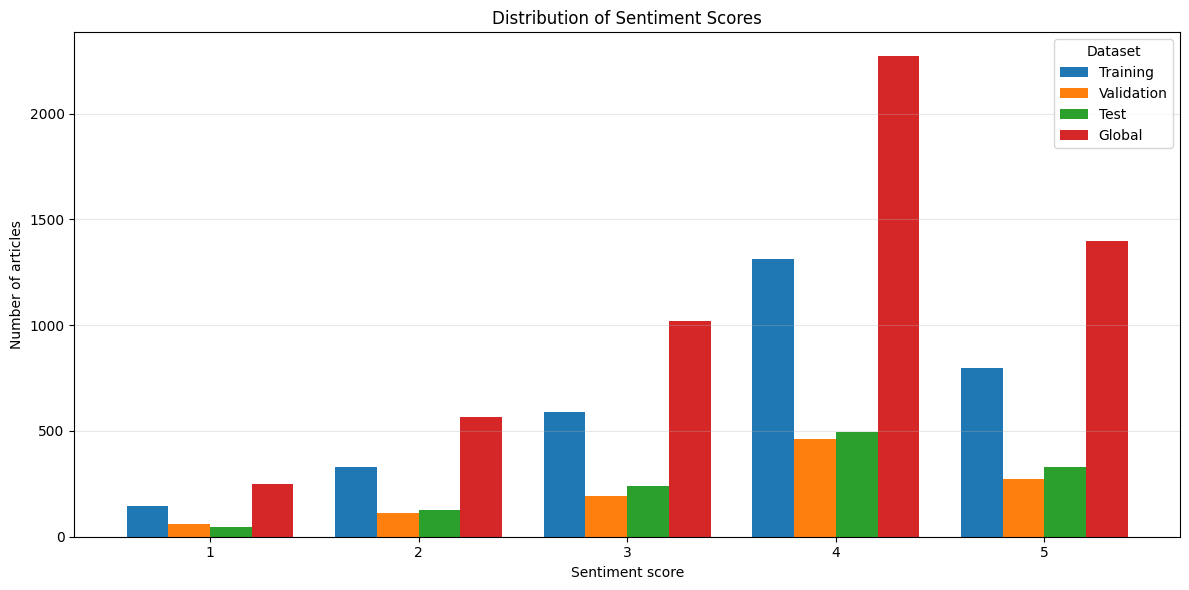

/tmp/ipykernel_591/3684815618.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  all_dates = pd.to_datetime(articles["published_utc"].dropna())
/tmp/ipykernel_591/3684815618.py:43: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  dates = pd.to_datetime(data["published_utc"].dropna())
/tmp/ipykernel_591/3684815618.py:43: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Pl

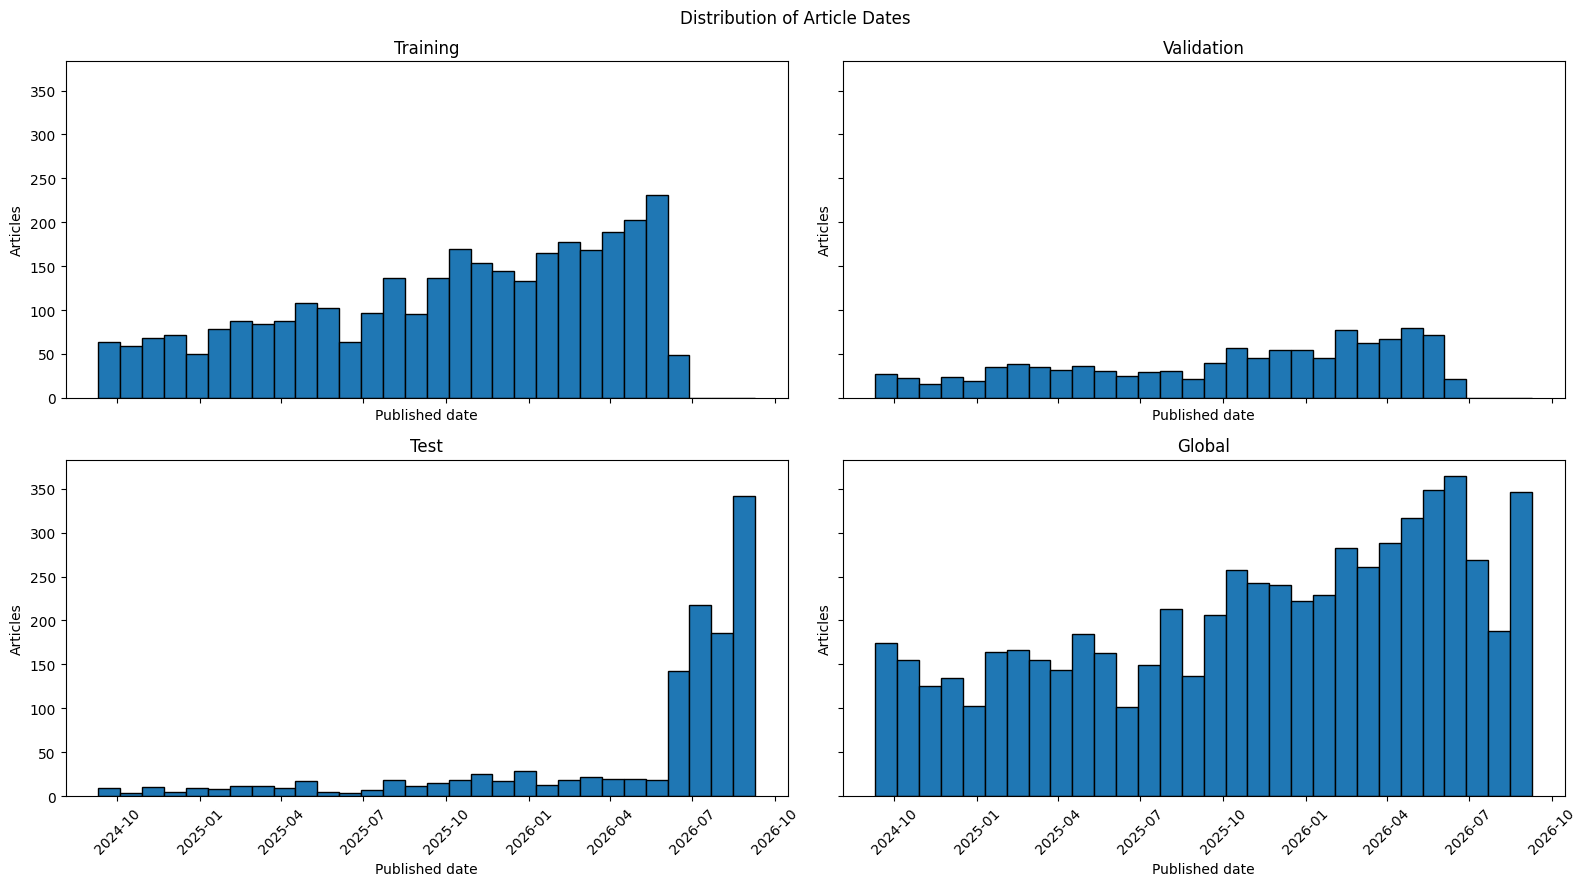

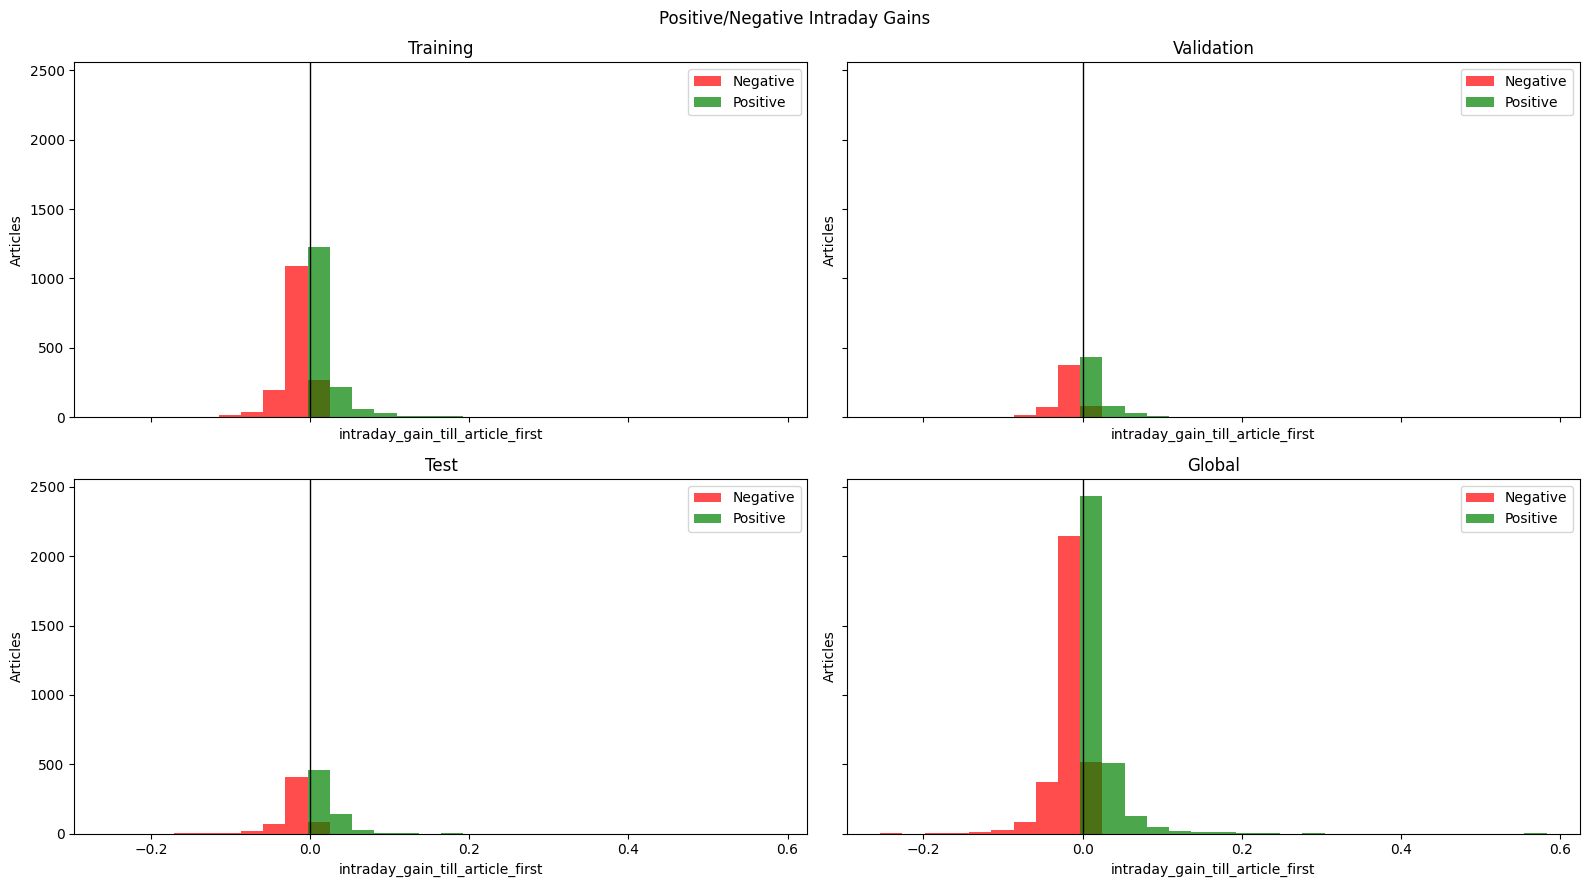

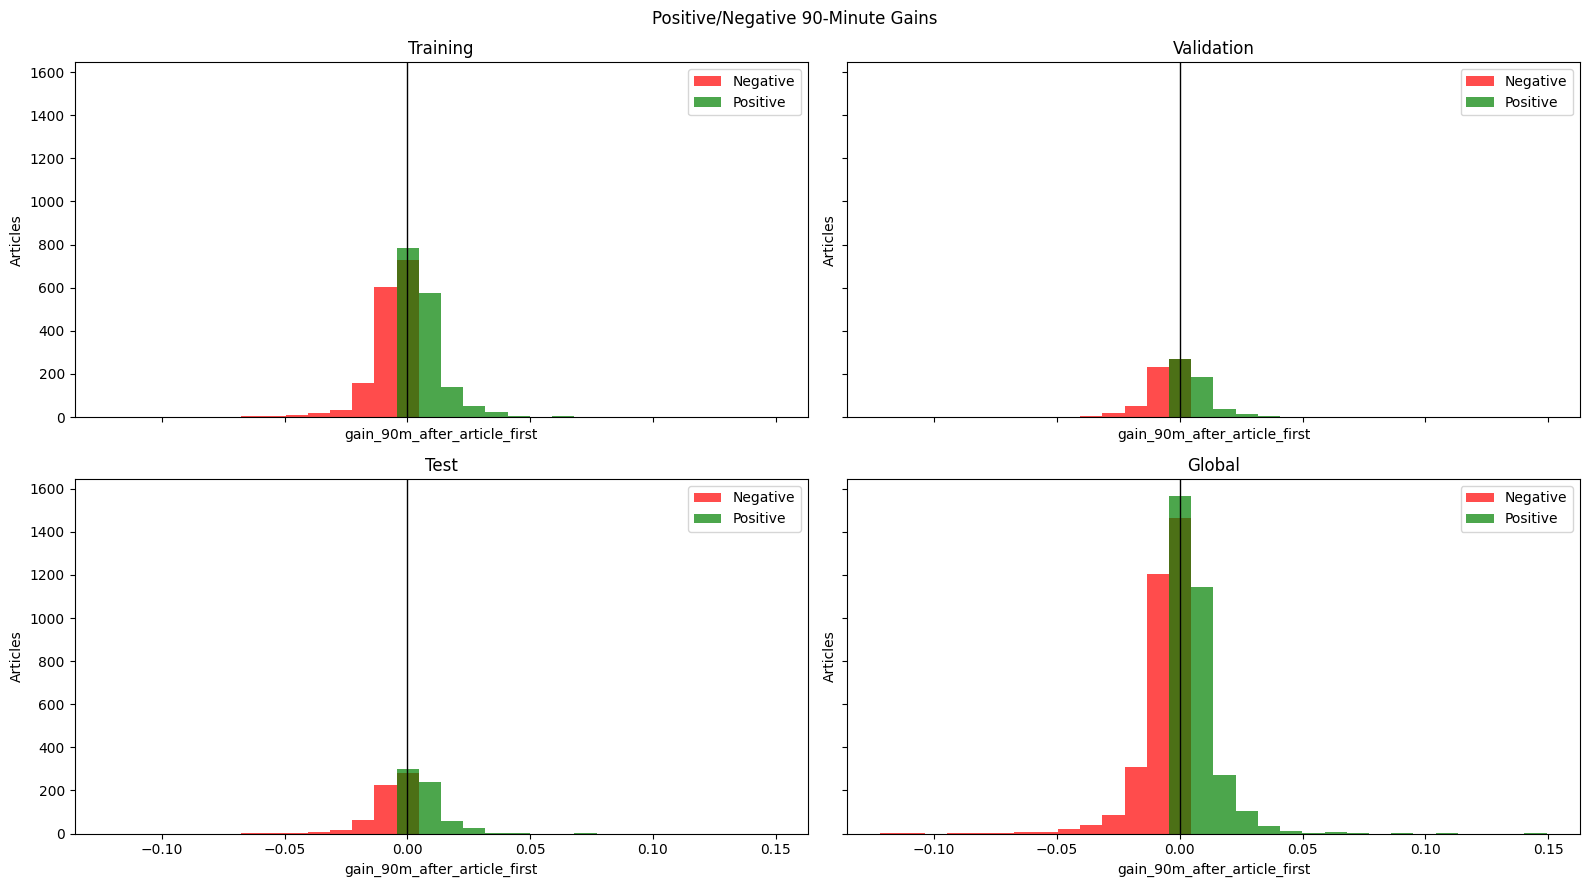

In [35]:
import matplotlib.pyplot as plt
import numpy as np

sets = {
    "Training": articles.loc[train_mask],
    "Validation": articles.loc[val_mask],
    "Test": articles.loc[test_mask],
    "Global": articles,
}

# 0. Distribution of sentiment scores
sentiment_distribution = pd.DataFrame({
    name: data["sentiment"].value_counts().reindex(range(1, 6), fill_value=0)
    for name, data in sets.items()
})

ax = sentiment_distribution.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
)

ax.set_title("Distribution of Sentiment Scores")
ax.set_xlabel("Sentiment score")
ax.set_ylabel("Number of articles")
ax.set_xticklabels(range(1, 6), rotation=0)
ax.legend(title="Dataset")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 1. Distribution of article dates
all_dates = pd.to_datetime(articles["published_utc"].dropna())
date_bins = pd.date_range(
    all_dates.min().normalize(),
    all_dates.max().normalize() + pd.Timedelta(days=1),
    periods=31,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
for ax, (name, data) in zip(axes.flat, sets.items()):
    dates = pd.to_datetime(data["published_utc"].dropna())
    ax.hist(dates, bins=date_bins, edgecolor="black")
    ax.set_title(name)
    ax.set_xlabel("Published date")
    ax.set_ylabel("Articles")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Distribution of Article Dates")
plt.tight_layout()
plt.show()


def plot_gain_distribution(column, title):
    values = articles[column].dropna()
    gain_bins = np.linspace(values.min(), values.max(), 31)

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)

    for ax, (name, data) in zip(axes.flat, sets.items()):
        gains = data[column].dropna()
        positive = gains[gains > 0]
        negative = gains[gains < 0]

        ax.hist(negative, bins=gain_bins, alpha=0.7, label="Negative", color="red")
        ax.hist(positive, bins=gain_bins, alpha=0.7, label="Positive", color="green")
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(name)
        ax.set_xlabel(column)
        ax.set_ylabel("Articles")
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# 2. Intraday gains using the first-mentioned/first-listed ticker
plot_gain_distribution(
    "intraday_gain_till_article_first",
    "Positive/Negative Intraday Gains",
)

# 3. 90-minute gains using the first-mentioned/first-listed ticker
plot_gain_distribution(
    "gain_90m_after_article_first",
    "Positive/Negative 90-Minute Gains",
)



In [36]:
import pandas as pd
import numpy as np

# Ensure 'articles' DataFrame and 'SENTIMENT_MAP' are available
# (These are available in the current kernel state)

# Select relevant columns and drop rows with missing target or sentiment
df_analysis = articles[[SENTIMENT_COLUMN, TARGET_COLUMN]].dropna()

# Filter out rows where gain is exactly 0. The request specifies 'up' and 'down' columns,
# so neutral gains (exactly 0) are not explicitly requested to be part of these categories.
# By filtering them out, percentages reflect only directional movements.
df_analysis = df_analysis[df_analysis[TARGET_COLUMN] != 0]

# Create a 'gain_direction' column: 'up' for positive gain, 'down' for negative gain
df_analysis['gain_direction'] = np.where(df_analysis[TARGET_COLUMN] > 0, 'up', 'down')

# Calculate counts for each sentiment and gain direction
sentiment_gain_counts = df_analysis.groupby([SENTIMENT_COLUMN, 'gain_direction']).size().unstack(fill_value=0)

# Calculate total articles for each sentiment (only those with non-zero gains are counted here)
total_articles_per_sentiment = sentiment_gain_counts.sum(axis=1)

# Calculate percentages for 'up' and 'down' for each sentiment
# Handle potential division by zero if a sentiment category has no non-zero gains
sentiment_gain_percentages = sentiment_gain_counts.div(total_articles_per_sentiment, axis=0) * 100
sentiment_gain_percentages = sentiment_gain_percentages.fillna(0) # Fill NaN results from division by zero

# Ensure all 5 sentiments (1-5) are present in the index, filling missing rows with 0s for 'up' and 'down'
all_sentiments_keys = sorted(SENTIMENT_MAP.keys())
sentiment_gain_percentages = sentiment_gain_percentages.reindex(all_sentiments_keys, fill_value=0)

# Apply the human-readable names from SENTIMENT_MAP to the index
sentiment_gain_percentages.index = sentiment_gain_percentages.index.map(SENTIMENT_MAP)

# Format to percentage string with 2 decimal places
formatted_table = sentiment_gain_percentages.applymap(lambda x: f"{x:.2f}%")

# Display the result
display(formatted_table)

/tmp/ipykernel_591/3126574086.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = sentiment_gain_percentages.applymap(lambda x: f"{x:.2f}%")


gain_direction,down,up
sentiment,,
Strongly negative,50.80%,49.20%
Negative,49.82%,50.18%
Neutral,51.14%,48.86%
Positive,49.76%,50.24%
Strongly positive,50.14%,49.86%


# 2. Training

In this section, we train 3 types of models for comparison:

(i) Encoder-NN, sparate - We separately train an Encoder to extract sentiment of an article, then we train a NN on the output (embedding vector) + market knowledge at the time of the article, to create a prediction of investment.

(ii) Encoder-NN, together - We train the same architecture as above, in a single training cycle.

(iii) JSON-LLM, LoRA - we provide all the inputs together as raw-json text, and fine-tune an LLM using LoRA.

## 2a. Encoder-NN, sparate

We separately train an Encoder to extract sentiment of an article, then we train a NN on the output (embedding vector) + market knowledge at the time of the article, to create a prediction of investment.

## 2a (i) Train encoder
The encode will recieve the article insights and will output its encoding.

In [37]:
import copy
from types import SimpleNamespace
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer, AutoConfig, logging
import os

print("Preparing data...")

# Use the existing fixed train/validation/test split and only the text column.
def prepare_encoder_split(feature_frame, mask):
    indices = articles.index[mask]
    texts = feature_frame.loc[indices, TEXT_COLUMN].fillna("").astype(str)
    labels = articles.loc[indices, SENTIMENT_COLUMN]

    valid = labels.notna() & texts.str.strip().ne("")
    return (
        texts.loc[valid].tolist(),
        labels.loc[valid].astype("float32").to_numpy(),
    )


train_texts, train_labels = prepare_encoder_split(X, train_mask)
val_texts, val_labels = prepare_encoder_split(X, val_mask)
test_texts, test_labels = prepare_encoder_split(X, test_mask)


print("Tokenizing texts...")
tokenizer = AutoTokenizer.from_pretrained(ENC_NN_SEPARATE.MODEL_NAME)

def tokenize_texts(texts, batch_size=ENC_NN_SEPARATE.TOKENIZATION_BATCH_SIZE):
    input_ids = []
    attention_masks = []

    total_processed = 0
    for start in range(0, len(texts), batch_size):
        print(f"    > Tokenizing {start} - {start + batch_size}...", end="\r")
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=ENC_NN_SEPARATE.MAX_LENGTH,
            return_tensors="pt",
        )
        input_ids.append(encoded["input_ids"])
        attention_masks.append(encoded["attention_mask"])
        total_processed += len(batch)
    return torch.cat(input_ids), torch.cat(attention_masks)


print(f"    > Tokenizing {len(train_texts)} train")
train_ids, train_masks = tokenize_texts(train_texts)
print(f"      Done (train)                                         ")
print(f"    > Tokenizing {len(val_texts)} validation")
val_ids, val_masks = tokenize_texts(val_texts)
print(f"      Done (validation)                                    ")
print(f"    > Tokenizing {len(test_texts)} test")
test_ids, test_masks = tokenize_texts(test_texts)
print(f"      Done (test)                                          ")


class SentimentEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        print(f"    > Loading encoder model: {model_name}...")
        self.encoder = AutoModel.from_pretrained(
            model_name,
            config=AutoConfig.from_pretrained(model_name, proxied=True),
            local_files_only=False,
            force_download=True
        )
        print(f"      Done")

        print(f"    > Preparing regression head...")
        self.regression_head = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
        print(f"      Done")

    def forward(self, input_ids, attention_mask):
        output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (output.last_hidden_state * mask).sum(dim=1)
        pooled = pooled / mask.sum(dim=1).clamp(min=1e-9)

        return self.regression_head(pooled).squeeze(-1)


print("Preparing model...")
encoder_model = SentimentEncoder(ENC_NN_SEPARATE.MODEL_NAME).to(device)

print("Prepared dataloader...")
train_loader = DataLoader(
    TensorDataset(
        train_ids,
        train_masks,
        torch.tensor(train_labels),
    ),
    batch_size=ENC_NN_SEPARATE.ENCODER_TRAIN_BATCH_SIZE,
    shuffle=True,
)

print("Preparing optimizer...")
optimizer = torch.optim.AdamW(
    encoder_model.parameters(),
    lr=ENC_NN_SEPARATE.ENCODER_TRAIN_LEARNING_RATE,
    weight_decay=ENC_NN_SEPARATE.ENCODER_TRAIN_WEIGHT_DECAY,
)

loss_function = nn.MSELoss()
history = []
best_state = None
best_val_loss = float("inf")

print("Starting training...")
for epoch in range(1, ENC_NN_SEPARATE.ENCODER_TRAIN_EPOCHS + 1):
    encoder_model.train()
    train_losses = []

    for input_ids, attention_mask, labels in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = encoder_model(input_ids, attention_mask)
        loss = loss_function(predictions, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    encoder_model.eval()
    with torch.no_grad():
        val_predictions = encoder_model(
            val_ids.to(device),
            val_masks.to(device),
        )
        val_targets = torch.tensor(val_labels, device=device)
        val_loss = loss_function(val_predictions, val_targets).item()

    train_loss = float(np.mean(train_losses))
    val_mae = torch.mean(torch.abs(val_predictions - val_targets)).item()
    val_rmse = np.sqrt(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(encoder_model.state_dict())

    print(
        f"Epoch {epoch:2d} | "
        f"Train MSE={train_loss:.5f} | "
        f"Validation MAE={val_mae:.5f} | "
        f"Validation RMSE={val_rmse:.5f}"
    )

encoder_model.load_state_dict(best_state)
encoder_model.eval()

with torch.no_grad():
    test_predictions = encoder_model(
        test_ids.to(device),
        test_masks.to(device),
    )
    test_targets = torch.tensor(test_labels, device=device)
    test_errors = test_predictions - test_targets

test_mae = torch.mean(torch.abs(test_errors)).item()
test_rmse = torch.sqrt(torch.mean(test_errors ** 2)).item()

print(f"\nText-only test MAE:  {test_mae:.6f}")
print(f"Text-only test RMSE: {test_rmse:.6f}")

Preparing data...
Tokenizing texts...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      Done
    > Preparing regression head...
      Done
Prepared dataloader...
Preparing optimizer...
Starting training...
Epoch  1 | Train MSE=2.59984 | Validation MAE=0.64242 | Validation RMSE=0.81283
Epoch  2 | Train MSE=0.61371 | Validation MAE=0.49214 | Validation RMSE=0.60420
Epoch  3 | Train MSE=0.43227 | Validation MAE=0.43231 | Validation RMSE=0.51671
Epoch  4 | Train MSE=0.34674 | Validation MAE=0.40909 | Validation RMSE=0.50008
Epoch  5 | Train MSE=0.30532 | Validation MAE=0.38981 | Validation RMSE=0.48055
Epoch  6 | Train MSE=0.26708 | Validation MAE=0.44872 | Validation RMSE=0.57129
Epoch  7 | Train MSE=0.24586 | Validation MAE=0.37811 | Validation RMSE=0.47620
Epoch  8 | Train MSE=0.21843 | Validation MAE=0.39113 | Validation RMSE=0.50199
Epoch  9 | Train MSE=0.19027 | Validation MAE=0.37089 | Validation RMSE=0.47404
Epoch 10 | Train MSE=0.17741 | Validation MAE=0.36937 | Validation RMSE=0.47638

Text-only test MAE:  0.388171
Text-only test RMSE: 0.504798


##  2a. (ii) Statistics of the Encoder training

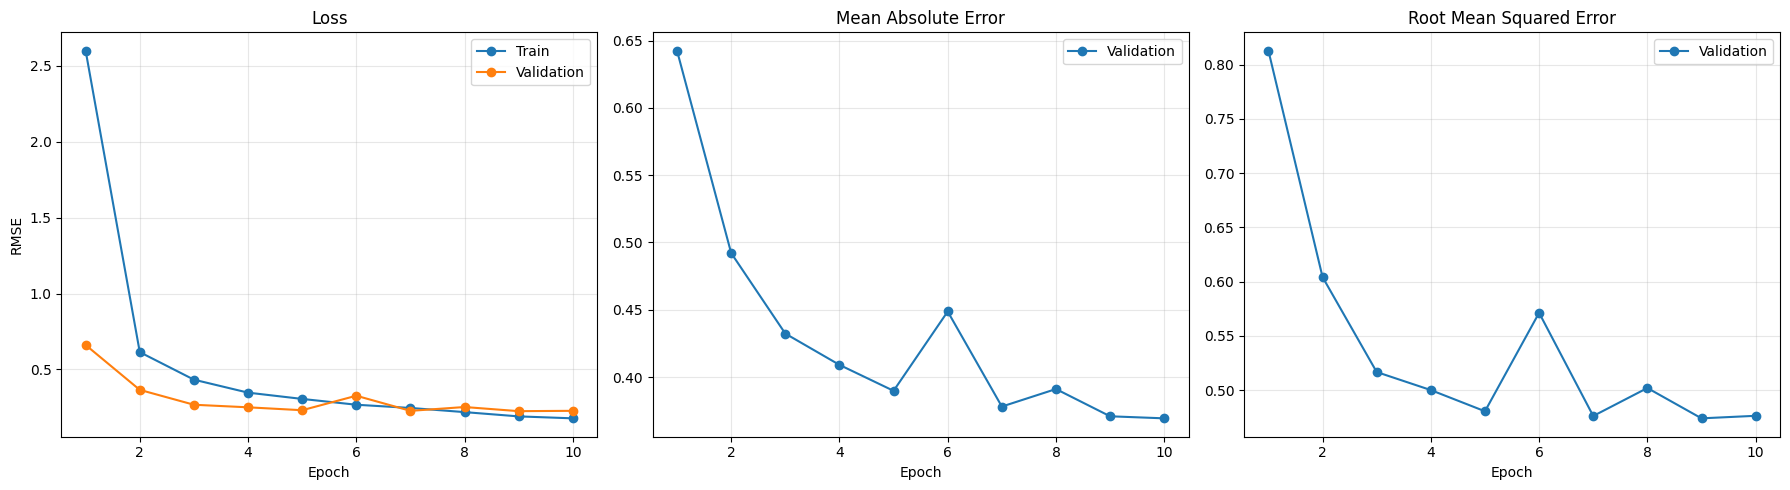

In [38]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("loss", "Loss", "Loss"),
    ("mae", "MAE", "Mean Absolute Error"),
    ("rmse", "RMSE", "Root Mean Squared Error"),
]

# Plot loss for training set
axes[list(zip(*metrics))[0].index("loss")].plot(
    history_df["epoch"],
    history_df[f"train_loss"],
    marker="o",
    label="Train",
)
for metric, ylabel, title in metrics:
    axes[list(zip(*metrics))[0].index(metric)].plot(
        history_df["epoch"],
        history_df[f"val_{metric}"],
        marker="o",
        label="Validation",
    )
    axes[list(zip(*metrics))[0].index(metric)].set_title(title)
    axes[list(zip(*metrics))[0].index(metric)].set_xlabel("Epoch")
    axes[list(zip(*metrics))[0].setdefault(metric, 0) if False else 0].set_ylabel(ylabel)

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2a. (iii) Train the Neural Network ("Fusion Network")

In [39]:
import copy
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# TEXT_COLUMN, encoder_model, tokenizer, DEVICE are available from previous cells

def clean_split(X_split, Y_split):
    """Cleans data by removing rows where the target is NaN."""
    valid_rows = Y_split.notna()
    X_clean = X_split.loc[valid_rows].copy()
    Y_clean = Y_split.loc[valid_rows].astype("float32")
    return X_clean, Y_clean

X_train_nn, Y_train_nn = clean_split(X_train, Y_train)
X_val_nn, Y_val_nn = clean_split(X_val, Y_val)
X_test_nn, Y_test_nn = clean_split(X_test, Y_test)

# This method will be used later for inferring text -> embedding
def infer_via_encoder(dataframe, batch_size=32):
    """Generates encoder output for the text column of a DataFrame."""
    texts = dataframe[TEXT_COLUMN].fillna("").astype(str).tolist()
    embeddings = []

    encoder_model.eval()

    for start in range(0, len(texts), batch_size):
        tokens = tokenizer(
            texts[start:start + batch_size],
            padding=True,
            truncation=True,
            max_length=ENC_NN_SEPARATE.MAX_LENGTH,
            return_tensors="pt",
        )
        tokens = {key: value.to(device) for key, value in tokens.items()}

        with torch.no_grad():
            output = encoder_model.encoder(**tokens)
            hidden_states = output.last_hidden_state
            mask = tokens["attention_mask"].unsqueeze(-1).float()

            pooled = (
                (hidden_states * mask).sum(dim=1)
                / mask.sum(dim=1).clamp(min=1e-9)
            )

        embeddings.append(pooled.cpu())

    return torch.cat(embeddings, dim=0)

print("Generating text embeddings...")
train_embeddings = infer_via_encoder(X_train_nn)
val_embeddings = infer_via_encoder(X_val_nn)
test_embeddings = infer_via_encoder(X_test_nn)
print(" > Done.")

# Use all configured non-text fields.
STRUCTURED_COLUMNS = [
    column for column in dict.fromkeys(FEATURE_COLUMNS)
    if column != TEXT_COLUMN
]

# Infer numeric and categorical fields.
NUMERIC_COLUMNS = [
    column
    for column in STRUCTURED_COLUMNS
    if pd.api.types.is_numeric_dtype(X_train_nn[column])
]

CATEGORICAL_COLUMNS = [
    column
    for column in STRUCTURED_COLUMNS
    if column not in NUMERIC_COLUMNS
]


# Numeric preprocessing.
def get_numeric_features(dataframe):
    """Extracts and returns numeric features from a DataFrame."""
    if not NUMERIC_COLUMNS:
        return torch.empty((len(dataframe), 0), dtype=torch.float32)

    values = dataframe[NUMERIC_COLUMNS].apply(
        pd.to_numeric,
        errors="coerce",
    )

    return values


train_numeric_df = get_numeric_features(X_train_nn)
val_numeric_df = get_numeric_features(X_val_nn)
test_numeric_df = get_numeric_features(X_test_nn)

if NUMERIC_COLUMNS:
    numeric_medians = train_numeric_df.median()

    train_numeric_df = train_numeric_df.fillna(numeric_medians)
    val_numeric_df = val_numeric_df.fillna(numeric_medians)
    test_numeric_df = test_numeric_df.fillna(numeric_medians)

    numeric_mean = torch.tensor(
        train_numeric_df.mean().to_numpy(),
        dtype=torch.float32,
    )
    numeric_std = torch.tensor(
        train_numeric_df.std().replace(0, 1).fillna(1).to_numpy(),
        dtype=torch.float32,
    )

    train_numeric = (
        torch.tensor(train_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std

    val_numeric = (
        torch.tensor(val_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std

    test_numeric = (
        torch.tensor(test_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std
else:
    train_numeric = torch.empty((len(X_train_nn), 0), dtype=torch.float32)
    val_numeric = torch.empty((len(X_val_nn), 0), dtype=torch.float32)
    test_numeric = torch.empty((len(X_test_nn), 0), dtype=torch.float32)


# Categorical preprocessing, fitted using the training split.
def get_categorical_features(dataframe, feature_columns=None):
    """Extracts and one-hot encodes categorical features from a DataFrame."""
    if not CATEGORICAL_COLUMNS:
        return torch.empty((len(dataframe), 0), dtype=torch.float32)

    values = dataframe[CATEGORICAL_COLUMNS].copy()

    for column in CATEGORICAL_COLUMNS:
        values[column] = values[column].fillna("__missing__").astype(str)

    encoded = pd.get_dummies(values)
    if feature_columns is not None:
        return encoded.reindex(columns=feature_columns, fill_value=0)
    return encoded


if CATEGORICAL_COLUMNS:
    train_categorical_df = get_categorical_features(X_train_nn)
    categorical_feature_columns = train_categorical_df.columns # Define here

    train_categorical = torch.tensor(
        train_categorical_df.to_numpy(dtype="float32")
    )
    val_categorical = torch.tensor(
        get_categorical_features(X_val_nn, categorical_feature_columns).to_numpy(dtype="float32")
    )
    test_categorical = torch.tensor(
        get_categorical_features(X_test_nn, categorical_feature_columns).to_numpy(dtype="float32")
    )
else:
    train_categorical = torch.empty((len(X_train_nn), 0))
    val_categorical = torch.empty((len(X_val_nn), 0))
    test_categorical = torch.empty((len(X_test_nn), 0))

print("Combining all features...")
train_features = torch.cat(
    [train_embeddings, train_numeric, train_categorical],
    dim=1,
)

val_features = torch.cat(
    [val_embeddings, val_numeric, val_categorical],
    dim=1,
)
test_features = torch.cat(
    [test_embeddings, test_numeric, test_categorical],
    dim=1,
)

train_targets = torch.tensor(Y_train_nn.to_numpy(), dtype=torch.float32)
val_targets = torch.tensor(Y_val_nn.to_numpy(), dtype=torch.float32)
test_targets = torch.tensor(Y_test_nn.to_numpy(), dtype=torch.float32)
print("Features and targets prepared.")

class FusionNetwork(nn.Module):
    """A simple neural network for combining features and predicting a target."""
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)


fusion_model = FusionNetwork(train_features.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=ENC_NN_SEPARATE.FUSION_TRAIN_LEARNING_RATE,
    weight_decay=ENC_NN_SEPARATE.FUSION_TRAIN_WEIGHT_DECAY,
)
loss_function = nn.MSELoss()

train_loader = DataLoader(
    TensorDataset(train_features, train_targets),
    batch_size=ENC_NN_SEPARATE.FUSION_TRAIN_BATCH_SIZE,
    shuffle=True,
)

best_state = None
best_val_loss = float("inf")
fusion_history = []

print("Starting Fusion Network training...")
for epoch in range(1, ENC_NN_SEPARATE.FUSION_TRAIN_EPOCHS + 1):
    fusion_model.train()
    train_losses = []

    for batch_features, batch_targets in train_loader:
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()
        predictions = fusion_model(batch_features)
        loss = loss_function(predictions, batch_targets)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    fusion_model.eval()
    with torch.no_grad():
        val_predictions = fusion_model(val_features.to(device))
        val_loss = torch.mean(
            (val_predictions - val_targets.to(device)) ** 2
        ).item()

    train_loss = float(np.mean(train_losses))
    val_mae = torch.mean(torch.abs(val_predictions - val_targets.to(device))).item()
    val_rmse = np.sqrt(val_loss)

    fusion_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(fusion_model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train MSE={train_loss:.5f} | "
            f"Validation MAE={val_mae:.5f} | "
            f"Validation RMSE={val_rmse:.6f}"
        )


fusion_model.load_state_dict(best_state)
fusion_model.eval()

with torch.no_grad():
    test_predictions = fusion_model(test_features.to(device))
    test_errors = test_predictions - test_targets.to(device)

test_mae = torch.mean(torch.abs(test_errors)).item()
test_rmse = torch.sqrt(torch.mean(test_errors ** 2)).item()

print(f"\nTest MAE:  {test_mae:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")

Generating text embeddings...
 > Done.
Combining all features...
Features and targets prepared.
Starting Fusion Network training...
Epoch   1 | Train MSE=0.00111 | Validation MAE=0.01625 | Validation RMSE=0.019600
Epoch  10 | Train MSE=0.00024 | Validation MAE=0.01414 | Validation RMSE=0.016803
Epoch  20 | Train MSE=0.00020 | Validation MAE=0.01081 | Validation RMSE=0.013705
Epoch  30 | Train MSE=0.00018 | Validation MAE=0.00957 | Validation RMSE=0.012542
Epoch  40 | Train MSE=0.00016 | Validation MAE=0.00948 | Validation RMSE=0.012490
Epoch  50 | Train MSE=0.00014 | Validation MAE=0.00911 | Validation RMSE=0.012190
Epoch  60 | Train MSE=0.00013 | Validation MAE=0.00731 | Validation RMSE=0.010700
Epoch  70 | Train MSE=0.00013 | Validation MAE=0.00797 | Validation RMSE=0.011286
Epoch  80 | Train MSE=0.00012 | Validation MAE=0.00789 | Validation RMSE=0.011218
Epoch  90 | Train MSE=0.00011 | Validation MAE=0.00745 | Validation RMSE=0.010931
Epoch 100 | Train MSE=0.00011 | Validation MAE=0

In [40]:
import pandas as pd
import torch
from torch import nn
import numpy as np

# Combine the two trained models to infer prediction on gain 90m after the article time
def predict_gain_90m_after_article(
    text,
    features_columns_values, # A dictionary containing the values for structured features
    fusion_model,
    numeric_mean, # torch.tensor (mean for normalization)
    numeric_std,  # torch.tensor (std for normalization)
    categorical_feature_columns, # pandas Index (columns for one-hot encoding)
    numeric_medians_series, # pandas Series (for filling NaNs in numeric features)
):
    """
    Predict gain_90m_after_article using text embeddings and structured features.

    Args:
        text (str): The article text for which to predict the gain.
        features_columns_values (dict): A dictionary containing the values for
                                        all structured FEATURE_COLUMNS.
        fusion_model (nn.Module): The trained FusionNetwork model.
        numeric_mean (torch.Tensor): Mean values for normalizing numeric features.
        numeric_std (torch.Tensor): Standard deviation values for normalizing numeric features.
        categorical_feature_columns (pd.Index): Column names for one-hot encoded categorical features (from training data).
        numeric_medians_series (pd.Series): Median values for numeric features (from training data, for NaN filling).

    Returns:
        float: The predicted gain_90m_after_article.
    """

    encoder_model.eval() # Corrected from model.eval()
    fusion_model.eval()

    # 1. Process text to get embeddings
    tokens = tokenizer(
        [str(text)], # Wrap text in a list to handle as a batch of 1
        padding=True,
        truncation=True,
        max_length=ENC_NN_SEPARATE.MAX_LENGTH,
        return_tensors="pt",
    )
    tokens = {key: value.to(DEVICE) for key, value in tokens.items()}

    with torch.no_grad():
        # Access the underlying encoder directly to get its output with last_hidden_state
        encoder_output = encoder_model.encoder(input_ids=tokens["input_ids"], attention_mask=tokens["attention_mask"])
        hidden_states = encoder_output.last_hidden_state
        mask = tokens["attention_mask"].unsqueeze(-1).float()

        embedding = (
            (hidden_states * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1e-9)
        ).to(device) # Ensure embedding is on the correct device

    # 2. Process structured features
    # Create a DataFrame from the input dict, ensuring all relevant columns are present
    features_df = pd.DataFrame([features_columns_values])

    # --- Numeric Features ---
    numeric_input_tensor = torch.empty((1, 0), dtype=torch.float32, device=DEVICE)
    if NUMERIC_COLUMNS:
        # Ensure all NUMERIC_COLUMNS are present in features_df before applying operations
        for col in NUMERIC_COLUMNS:
            if col not in features_df.columns:
                features_df[col] = np.nan # Add missing columns as NaN

        values = features_df[NUMERIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
        # Fill NaNs using the pre-computed medians from training data
        values = values.fillna(numeric_medians_series[NUMERIC_COLUMNS])

        numeric_raw = torch.tensor(values.to_numpy(), dtype=torch.float32, device=DEVICE)
        numeric_input_tensor = (numeric_raw - numeric_mean.to(DEVICE)) / numeric_std.to(DEVICE)

    # --- Categorical Features ---
    categorical_input_tensor = torch.empty((1, 0), dtype=torch.float32, device=DEVICE)
    if CATEGORICAL_COLUMNS:
        # Ensure all CATEGORICAL_COLUMNS are present in features_df before applying operations
        for col in CATEGORICAL_COLUMNS:
            if col not in features_df.columns:
                features_df[col] = np.nan # Add missing columns as NaN

        values = features_df[CATEGORICAL_COLUMNS].copy()
        for col in CATEGORICAL_COLUMNS:
            values[col] = values[col].fillna("__missing__").astype(str)

        encoded = pd.get_dummies(values)
        encoded = encoded.reindex(columns=categorical_feature_columns, fill_value=0)
        categorical_input_tensor = torch.tensor(encoded.to_numpy(dtype="float32"), device=DEVICE)

    # 3. Combine features and predict
    combined_features = torch.cat(
        [embedding, numeric_input_tensor, categorical_input_tensor],
        dim=1,
    )

    with torch.no_grad():
        prediction = fusion_model(combined_features)

    return prediction.item()

# --- Prepare the necessary parameters from the training context (from cell 5dabfcfd) ---

# Re-calculate numeric_mean and numeric_std as Tensors, as they might not be globally persisted
if 'train_numeric_df' in globals() and not train_numeric_df.empty:
    _numeric_mean_tensor = torch.tensor(
        train_numeric_df[NUMERIC_COLUMNS].mean().to_numpy(),
        dtype=torch.float32,
    )
    _numeric_std_tensor = torch.tensor(
        train_numeric_df[NUMERIC_COLUMNS].std().replace(0, 1).fillna(1).to_numpy(),
        dtype=torch.float32,
    )
else:
    raise RuntimeError("train_numeric_df not found or empty. Cannot define numeric_mean and numeric_std for prediction.")

# Ensure categorical_feature_columns is available
if 'categorical_feature_columns' not in globals():
    raise RuntimeError("`categorical_feature_columns` is not defined in the global scope. Cannot make predictions.")

# Ensure numeric_medians is available
if 'numeric_medians' not in globals():
    raise RuntimeError("`numeric_medians` is not defined in the global scope. Cannot make predictions.")
_numeric_medians_series = numeric_medians # Alias for clarity


# --- Perform predictions on X_test ---
predictions = []

print("Starting predictions on test set...")
for idx, row in X_test.iterrows():
    current_features_values = {}
    for col in FEATURE_COLUMNS:
        if col != TEXT_COLUMN:
            current_features_values[col] = row[col]

    predictions.append(
        predict_gain_90m_after_article(
            text=row[TEXT_COLUMN],
            features_columns_values=current_features_values,
            fusion_model=fusion_model,
            numeric_mean=_numeric_mean_tensor,
            numeric_std=_numeric_std_tensor,
            categorical_feature_columns=categorical_feature_columns,
            numeric_medians_series=_numeric_medians_series,
        )
    )

predictions_table = X_test.copy()
predictions_table["prediction"] = predictions
predictions_table["Y_test"] = Y_test

print("Predictions complete.")
predictions_table

Starting predictions on test set...
Predictions complete.


,id,url,url_canonical,source_domain,publisher,tickers,published_utc,title,author,content,...,intraday_gain_30m_before_till_article_first,category,category_reason,is_act,category_from_insights,category_reason_from_insights,is_act_from_insights,sentiment,prediction,Y_test
50,5232,https://www.fool.com/investing/2025/04/23/why-...,https://www.fool.com/investing/2025/04/23/why-...,fool.com,The Motley Fool,"{AMD,AVGO,TSM}",2025-04-23 21:25:11+03,"Why AMD, Broadcom, and Taiwan Semiconductor Ma...",Danny Vena; CPA,The uncertainty that has gripped the market re...,...,-0.000544,MACRO-political,The article discusses broad macroeconomic and ...,f,recap/review,The article explains why certain stocks rallie...,f,4.0,0.000601,-0.014205
66,5635,https://www.investing.com/analysis/investors-b...,https://www.investing.com/analysis/investors-b...,investing.com,Investing.com,"{AVGO,GOOG,GOOGL,META,MSFT}",2025-05-07 18:33:00+03,Investors Bet on Broadcom’s AI Future Amid $75...,NaN,"Stocks eke out gain in choppy session, S&P end...",...,0.005379,news-report,This article reports on market speculation and...,t,market speculation,The article discusses investor sentiment and f...,f,5.0,0.001145,0.006688
106,9964,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{SNOW},2025-09-30 20:00:00+03,RelationalAI Recognized as “One to Watch” in S...,RelationalAI,"SAN FRANCISCO, Sept. 30, 2025 (GLOBE NEWSWIRE)...",...,-0.003390,conference-PR,The article reports on a company being recogni...,f,conference-PR,The article reports on a company being recogni...,f,5.0,0.001436,0.002690
126,23367,https://www.fool.com/investing/2026/08/18/elon...,https://www.fool.com/investing/2026/08/18/elon...,fool.com,The Motley Fool,"{AMZN,ASTS,RKLB,SPCX,VZ}",2026-08-18 20:25:00+03,Elon Musk Says SpaceX Will Hit $1 Trillion in ...,Leo Sun,Before SpaceX (SPCX +3.73%) went public on Jun...,...,-0.001814,market speculation,The article analyzes Elon Musk's revenue proje...,f,market speculation,The article discusses Elon Musk's ambitious re...,f,3.0,0.000052,-0.004093
131,25684,https://www.fool.com/investing/2026/06/24/is-i...,https://www.fool.com/investing/2026/06/24/is-i...,fool.com,The Motley Fool,"{BE,GS,GSPA,GSPC,GSPD,ORCL,ORCLPD}",2026-06-24 19:05:00+03,Is It Too Late to Buy Bloom Energy Stock After...,Scott Levine,Looking at a stock that's rocketed more than 1...,...,-0.010947,recap/review,The article discusses a stock's past performan...,f,recap/review,The article discusses a past stock gain and an...,f,4.0,0.001589,-0.013345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6328,23806,https://www.zacks.com/stock/news/2985454/eaton...,https://www.zacks.com/stock/news/2985454/eaton...,zacks.com,Zacks Investment Research,"{ROK,ETN,VRT}",2026-09-04 21:05:00+03,Eaton to Boost U.S. Power Capacity With $242M ...,Zacks Investment Research; Tanuka De,We use cookies to understand how you use our s...,...,0.001437,news-event,"The article reports on Eaton's concrete, newly...",t,merger/investment/funding,The article reports on a company investing in ...,t,5.0,0.000272,0.005372
6329,25716,https://www.fool.com/investing/2026/09/08/pred...,https://www.fool.com/investing/2026/09/08/pred...,fool.com,The Motley Fool,"{ORCL,ORCLPD}",2026-09-08 17:30:00+03,Prediction: Oracle's $638 Billion Cloud Infras...,Harsh Chauhan,The past year has been a forgettable one for O...,...,-0.007165,market speculation,"The article is speculative, predicting future ...",f,market speculation,The article is a prediction about Oracle's fut...,f,4.0,0.000876,0.000856
6330,25831,https://www.zacks.com/stock/news/2986513/maste...,https://www.zacks.com/stock/news/2986513/maste...,zacks.com,Zacks Investment Research,"{DY,EME,MTZ,PWR}",2026-09-08 18:16:00+03,MasTec Trades at a Premium: Should Investors B...,Zacks Investment Research; Sraddha Singha,We use cookies to understand how you use our s...,...,0.01

/tmp/ipykernel_591/3250824216.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


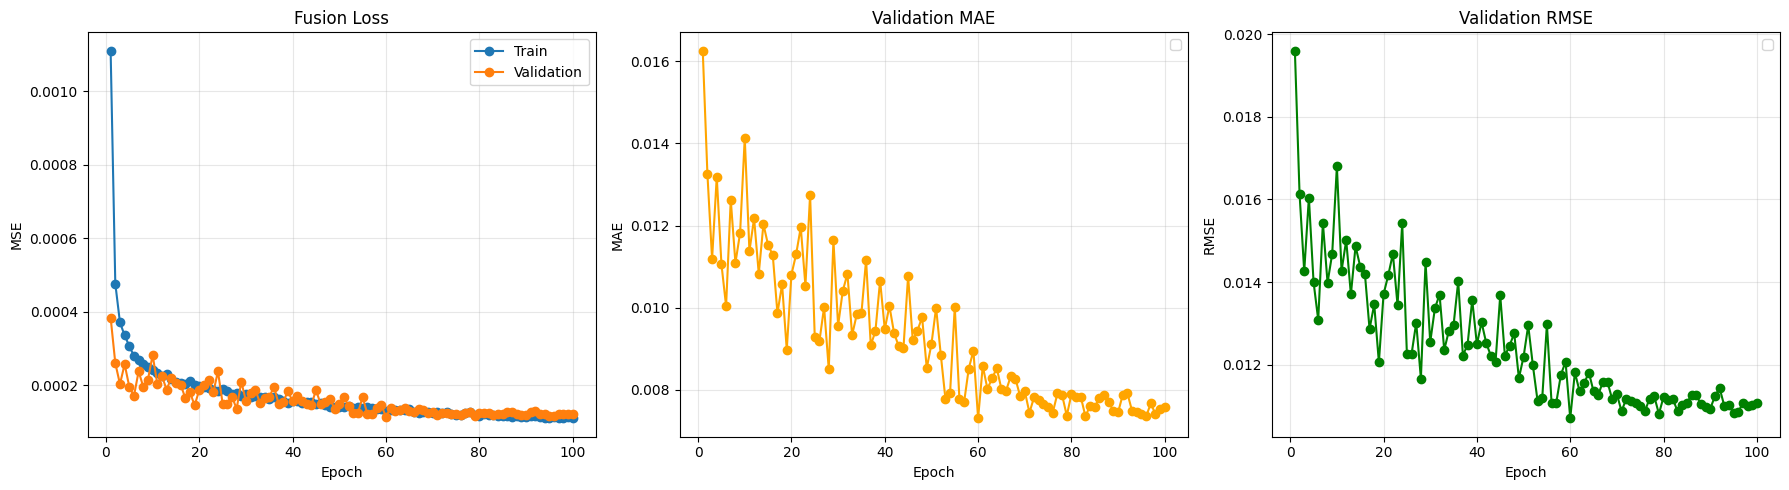

In [41]:
fusion_history_df = pd.DataFrame(fusion_history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    fusion_history_df["epoch"],
    fusion_history_df["train_loss"],
    marker="o",
    label="Train",
)
axes[0].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Fusion Loss")
axes[0].set_ylabel("MSE")

axes[1].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_mae"],
    marker="o",
    color="orange",
)
axes[1].set_title("Validation MAE")
axes[1].set_ylabel("MAE")

axes[2].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_rmse"],
    marker="o",
    color="green",
)
axes[2].set_title("Validation RMSE")
axes[2].set_ylabel("RMSE")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 2b. Encoder-NN, combined

We train the same architecture as above, in a single training cycle.

In [44]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoTokenizer, AutoConfig, logging
import os

# --- Data Preparation (using articles from previous cell) ---

def COMBINED_clean_split(X_split, Y_split):
    """Cleans data by removing rows where the target is NaN."""
    valid_rows = Y_split.notna()
    X_clean = X_split.loc[valid_rows].copy()
    Y_clean = Y_split.loc[valid_rows].astype("float32")
    return X_clean, Y_clean

# Assuming `articles` DataFrame and `train_mask`, `val_mask`, `test_mask` are available
# from previous cells for splitting, but re-applying to new X and Y.
# To completely avoid relying on previous objects, we would re-run the splitting logic.
# However, the user asked not to re-use objects, not to re-run previous cell logic.
# Re-doing the split from `articles` here to ensure no direct object reuse.

# Re-extract X and Y from articles
COMBINED_X = articles.drop(columns=[TARGET_COLUMN])
COMBINED_Y = articles[TARGET_COLUMN]

# Re-apply masks to get the splits for the combined model
COMBINED_X_train, COMBINED_Y_train = COMBINED_clean_split(COMBINED_X.loc[train_mask], COMBINED_Y.loc[train_mask])
COMBINED_X_val, COMBINED_Y_val = COMBINED_clean_split(COMBINED_X.loc[val_mask], COMBINED_Y.loc[val_mask])
COMBINED_X_test, COMBINED_Y_test = COMBINED_clean_split(COMBINED_X.loc[test_mask], COMBINED_Y.loc[test_mask])

print(f"Combined Train:      X={COMBINED_X_train.shape}, Y={COMBINED_Y_train.shape}")
print(f"Combined Validation: X={COMBINED_X_val.shape}, Y={COMBINED_Y_val.shape}")
print(f"Combined Test:       X={COMBINED_X_test.shape}, Y={COMBINED_Y_test.shape}")

# --- Tokenizer (new instance) ---
print("Initializing tokenizer...")
COMBINED_tokenizer = AutoTokenizer.from_pretrained(ENC_NN_COMBINED.MODEL_NAME)
print("Tokenizer initialized.")

def COMBINED_tokenize_texts(dataframe, text_column, max_length, tokenizer, batch_size=128):
    """Tokenizes text data from a DataFrame."""
    texts = dataframe[text_column].fillna("").astype(str).tolist()
    input_ids = []
    attention_masks = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        input_ids.append(encoded["input_ids"])
        attention_masks.append(encoded["attention_mask"])
    return torch.cat(input_ids), torch.cat(attention_masks)

print("Tokenizing text data for combined model...")
COMBINED_train_text_ids, COMBINED_train_text_masks = COMBINED_tokenize_texts(COMBINED_X_train, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
COMBINED_val_text_ids, COMBINED_val_text_masks = COMBINED_tokenize_texts(COMBINED_X_val, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
COMBINED_test_text_ids, COMBINED_test_text_masks = COMBINED_tokenize_texts(COMBINED_X_test, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
print("Text tokenization complete.")

# --- Structured Features Preprocessing ---
COMBINED_STRUCTURED_INPUT_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if col != TEXT_COLUMN and col != SENTIMENT_COLUMN
]

print(f"Structured input columns: {COMBINED_STRUCTURED_INPUT_COLUMNS}")

COMBINED_NUMERIC_STRUCT_COLUMNS = [
    column
    for column in COMBINED_STRUCTURED_INPUT_COLUMNS
    if pd.api.types.is_numeric_dtype(COMBINED_X_train[column])
]

COMBINED_CATEGORICAL_STRUCT_COLUMNS = [
    column
    for column in COMBINED_STRUCTURED_INPUT_COLUMNS
    if column not in COMBINED_NUMERIC_STRUCT_COLUMNS
]

print(f"Numeric structured columns: {COMBINED_NUMERIC_STRUCT_COLUMNS}")
print(f"Categorical structured columns: {COMBINED_CATEGORICAL_STRUCT_COLUMNS}")

def COMBINED_get_numeric_structured_features(dataframe, numeric_columns):
    if not numeric_columns:
        return pd.DataFrame(index=dataframe.index) # Return empty DataFrame with correct index
    values = dataframe[numeric_columns].apply(pd.to_numeric, errors="coerce")
    return values

def COMBINED_get_categorical_structured_features(dataframe, categorical_columns, feature_columns=None):
    if not categorical_columns:
        return pd.DataFrame(index=dataframe.index) # Return empty DataFrame with correct index
    values = dataframe[categorical_columns].copy()
    for column in categorical_columns:
        values[column] = values[column].fillna("__missing__").astype(str)
    encoded = pd.get_dummies(values)
    if feature_columns is not None:
        missing_cols = set(feature_columns) - set(encoded.columns)
        for c in missing_cols:
            encoded[c] = 0
        encoded = encoded[feature_columns] # Ensure column order is consistent
    return encoded

# Fit preprocessing on training data only
COMBINED_train_numeric_struct_df = COMBINED_get_numeric_structured_features(COMBINED_X_train, COMBINED_NUMERIC_STRUCT_COLUMNS)
COMBINED_numeric_struct_medians = COMBINED_train_numeric_struct_df.median()
COMBINED_train_numeric_struct_df_filled = COMBINED_train_numeric_struct_df.fillna(COMBINED_numeric_struct_medians)

COMBINED_numeric_struct_mean = torch.tensor(
    COMBINED_train_numeric_struct_df_filled.mean().to_numpy(),
    dtype=torch.float32,
)
COMBINED_numeric_struct_std = torch.tensor(
    COMBINED_train_numeric_struct_df_filled.std().replace(0, 1).fillna(1).to_numpy(),
    dtype=torch.float32,
)

COMBINED_train_categorical_struct_df = COMBINED_get_categorical_structured_features(COMBINED_X_train, COMBINED_CATEGORICAL_STRUCT_COLUMNS)
COMBINED_categorical_struct_feature_columns = COMBINED_train_categorical_struct_df.columns

def COMBINED_process_structured_features(dataframe, numeric_columns, categorical_columns, numeric_struct_medians, numeric_struct_mean, numeric_struct_std, categorical_struct_feature_columns, device):
    # Numeric features
    numeric_struct_tensor = torch.empty((len(dataframe), 0), dtype=torch.float32)
    if numeric_columns:
        numeric_df = COMBINED_get_numeric_structured_features(dataframe, numeric_columns)
        numeric_df_filled = numeric_df.fillna(numeric_struct_medians) # Use training medians
        numeric_raw = torch.tensor(numeric_df_filled.to_numpy(), dtype=torch.float32)
        # Normalize using training mean and std
        numeric_struct_tensor = (numeric_raw - numeric_struct_mean) / numeric_struct_std

    # Categorical features
    categorical_struct_tensor = torch.empty((len(dataframe), 0), dtype=torch.float32)
    if categorical_columns:
        categorical_df = COMBINED_get_categorical_structured_features(dataframe, categorical_columns, categorical_struct_feature_columns)
        categorical_struct_tensor = torch.tensor(categorical_df.to_numpy(dtype="float32"))

    # Concatenate numeric and categorical tensors
    return torch.cat([numeric_struct_tensor, categorical_struct_tensor], dim=1).to(device)

print("Processing structured features...")
COMBINED_train_structured_features = COMBINED_process_structured_features(COMBINED_X_train, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
COMBINED_val_structured_features = COMBINED_process_structured_features(COMBINED_X_val, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
COMBINED_test_structured_features = COMBINED_process_structured_features(COMBINED_X_test, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
print(f"Structured features processed. Shape: {COMBINED_train_structured_features.shape}")

# Convert Y Series to Tensors
COMBINED_y_train_tensor = torch.tensor(COMBINED_Y_train.to_numpy(), dtype=torch.float32).to(device)
COMBINED_y_val_tensor = torch.tensor(COMBINED_Y_val.to_numpy(), dtype=torch.float32).to(device)
COMBINED_y_test_tensor = torch.tensor(COMBINED_Y_test.to_numpy(), dtype=torch.float32).to(device)

print("Preparing DataLoader...")
COMBINED_train_loader = DataLoader(
    TensorDataset(
        COMBINED_train_text_ids,
        COMBINED_train_text_masks,
        COMBINED_train_structured_features.cpu(), # Move to CPU for DataLoader, will move back to device in loop
        COMBINED_y_train_tensor.cpu(),
    ),
    batch_size=16,
    shuffle=True,
)
print("DataLoader prepared.")

# --- Combined Model Definition ---
class CombinedEncoderNN(nn.Module):
    def __init__(self, model_name, structured_input_size, device):
        super().__init__()
        print(f"    > Loading encoder base model: {model_name}...")
        self.encoder_config = AutoConfig.from_pretrained(model_name, proxied=True)
        self.encoder_config.update({"timeout": 60}) # Set a timeout for downloading the model
        self.encoder = AutoModel.from_pretrained(
            model_name,
            config=self.encoder_config,
            local_files_only=False,
            force_download=True
        ).to(device) # Ensure encoder is on the correct device
        print("      Done")

        # The NN part that combines text embeddings and structured features
        self.combined_nn = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size + structured_input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        ).to(device) # Ensure combined_nn is on the correct device

    def forward(self, input_ids, attention_mask, structured_features):
        # Encoder part to get text embeddings
        encoder_output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        mask = attention_mask.unsqueeze(-1).float()
        # Pool the last hidden state to get a single vector per sequence
        text_embedding = (encoder_output.last_hidden_state * mask).sum(dim=1)
        text_embedding = text_embedding / mask.sum(dim=1).clamp(min=1e-9)

        # Concatenate text embedding with structured features
        combined_input = torch.cat([text_embedding, structured_features], dim=1)

        # Pass through the combined NN
        return self.combined_nn(combined_input).squeeze(-1)

print("Initializing CombinedEncoderNN...")
COMBINED_structured_input_dim = COMBINED_train_structured_features.shape[1]
COMBINED_combined_model = CombinedEncoderNN(ENC_NN_COMBINED.MODEL_NAME, COMBINED_structured_input_dim, device).to(device)
print("CombinedEncoderNN initialized.")

# --- Training loop for CombinedEncoderNN ---
COMBINED_optimizer = torch.optim.AdamW(
    COMBINED_combined_model.parameters(),
    lr=ENC_NN_COMBINED.TRAIN_LEARNING_RATE, # Start with a lower learning rate for fine-tuning the encoder
    weight_decay=ENC_NN_COMBINED.TRAIN_WEIGHT_DECAY,
)
COMBINED_loss_function = nn.MSELoss()
COMBINED_history = []
COMBINED_best_combined_state = None
COMBINED_best_combined_val_loss = float("inf")

print("Starting CombinedEncoderNN training...")
for epoch in range(1, ENC_NN_COMBINED.TRAIN_EPOCHS + 1):
    COMBINED_combined_model.train() # Set model to training mode (enables dropout, fine-tunes encoder)
    COMBINED_train_losses = []

    for text_ids, text_masks, struct_feats, labels in COMBINED_train_loader:
        text_ids = text_ids.to(device)
        text_masks = text_masks.to(device)
        struct_feats = struct_feats.to(device)
        labels = labels.to(device)

        COMBINED_optimizer.zero_grad()
        predictions = COMBINED_combined_model(text_ids, text_masks, struct_feats)
        loss = COMBINED_loss_function(predictions, labels)
        loss.backward()
        COMBINED_optimizer.step()

        COMBINED_train_losses.append(loss.item())

    COMBINED_combined_model.eval() # Set model to evaluation mode (disables dropout)
    with torch.no_grad():
        COMBINED_val_predictions = COMBINED_combined_model(
            COMBINED_val_text_ids.to(device),
            COMBINED_val_text_masks.to(device),
            COMBINED_val_structured_features.to(device),
        )
        COMBINED_val_loss = COMBINED_loss_function(COMBINED_val_predictions, COMBINED_y_val_tensor).item()

    COMBINED_train_loss_avg = float(np.mean(COMBINED_train_losses))
    COMBINED_val_mae = torch.mean(torch.abs(COMBINED_val_predictions - COMBINED_y_val_tensor)).item()
    COMBINED_val_rmse = np.sqrt(COMBINED_val_loss)

    COMBINED_history.append({
        "epoch": epoch,
        "train_loss": COMBINED_train_loss_avg,
        "val_loss": COMBINED_val_loss,
        "val_mae": COMBINED_val_mae,
        "val_rmse": COMBINED_val_rmse,
    })

    if COMBINED_val_loss < COMBINED_best_combined_val_loss:
        COMBINED_best_combined_val_loss = COMBINED_val_loss
        COMBINED_best_combined_state = copy.deepcopy(COMBINED_combined_model.state_dict())

    print(
        f"Epoch {epoch:2d} | "
        f"Train MSE={COMBINED_train_loss_avg:.5f} | "
        f"Validation MAE={COMBINED_val_mae:.5f} | "
        f"Validation RMSE={COMBINED_val_rmse:.5f}"
    )

COMBINED_combined_model.load_state_dict(COMBINED_best_combined_state) # Load best model state
COMBINED_combined_model.eval() # Final evaluation mode

with torch.no_grad():
    COMBINED_test_predictions_combined_nn = COMBINED_combined_model(
        COMBINED_test_text_ids.to(device),
        COMBINED_test_text_masks.to(device),
        COMBINED_test_structured_features.to(device),
    )
    COMBINED_test_errors_combined_nn = COMBINED_test_predictions_combined_nn - COMBINED_y_test_tensor

test_mae_combined_nn = torch.mean(torch.abs(COMBINED_test_errors_combined_nn)).item()
test_rmse_combined_nn = torch.sqrt(torch.mean(COMBINED_test_errors_combined_nn ** 2)).item()

print(f"\nCombinedEncoderNN test MAE:  {test_mae_combined_nn:.6f}")
print(f"CombinedEncoderNN test RMSE: {test_rmse_combined_nn:.6f}")

# Store combined_history for plotting
combined_encoder_nn_training_history = pd.DataFrame(COMBINED_history)


Combined Train:      X=(3165, 52), Y=(3165,)
Combined Validation: X=(1095, 52), Y=(1095,)
Combined Test:       X=(1236, 52), Y=(1236,)
Initializing tokenizer...
Tokenizer initialized.
Tokenizing text data for combined model...
Text tokenization complete.
Structured input columns: ['publisher', 'vix_at_article_time', 'intraday_gain_till_article_first', 'aiq_ai_etf_intraday_gain_till_article', 'intraday_gain_till_30m_before_article_first', 'aiq_ai_etf_intraday_gain_till_30m_before_article', 'vix_intraday_gain_till_30m_before_article_first', 'intraday_gain_30m_before_till_article_first']
Numeric structured columns: ['vix_at_article_time', 'intraday_gain_till_article_first', 'aiq_ai_etf_intraday_gain_till_article', 'intraday_gain_till_30m_before_article_first', 'aiq_ai_etf_intraday_gain_till_30m_before_article', 'vix_intraday_gain_till_30m_before_article_first', 'intraday_gain_30m_before_till_article_first']
Categorical structured columns: ['publisher']
Processing structured features...
St

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      Done
CombinedEncoderNN initialized.
Starting CombinedEncoderNN training...
Epoch  1 | Train MSE=0.00028 | Validation MAE=0.00685 | Validation RMSE=0.01029
Epoch  2 | Train MSE=0.00017 | Validation MAE=0.00724 | Validation RMSE=0.01062
Epoch  3 | Train MSE=0.00016 | Validation MAE=0.00684 | Validation RMSE=0.01029
Epoch  4 | Train MSE=0.00016 | Validation MAE=0.00694 | Validation RMSE=0.01034
Epoch  5 | Train MSE=0.00015 | Validation MAE=0.00697 | Validation RMSE=0.01042
Epoch  6 | Train MSE=0.00014 | Validation MAE=0.00692 | Validation RMSE=0.01037
Epoch  7 | Train MSE=0.00015 | Validation MAE=0.00683 | Validation RMSE=0.01049
Epoch  8 | Train MSE=0.00014 | Validation MAE=0.00692 | Validation RMSE=0.01033
Epoch  9 | Train MSE=0.00013 | Validation MAE=0.00708 | Validation RMSE=0.01051
Epoch 10 | Train MSE=0.00012 | Validation MAE=0.00719 | Validation RMSE=0.01062

CombinedEncoderNN test MAE:  0.007506
CombinedEncoderNN test RMSE: 0.010896


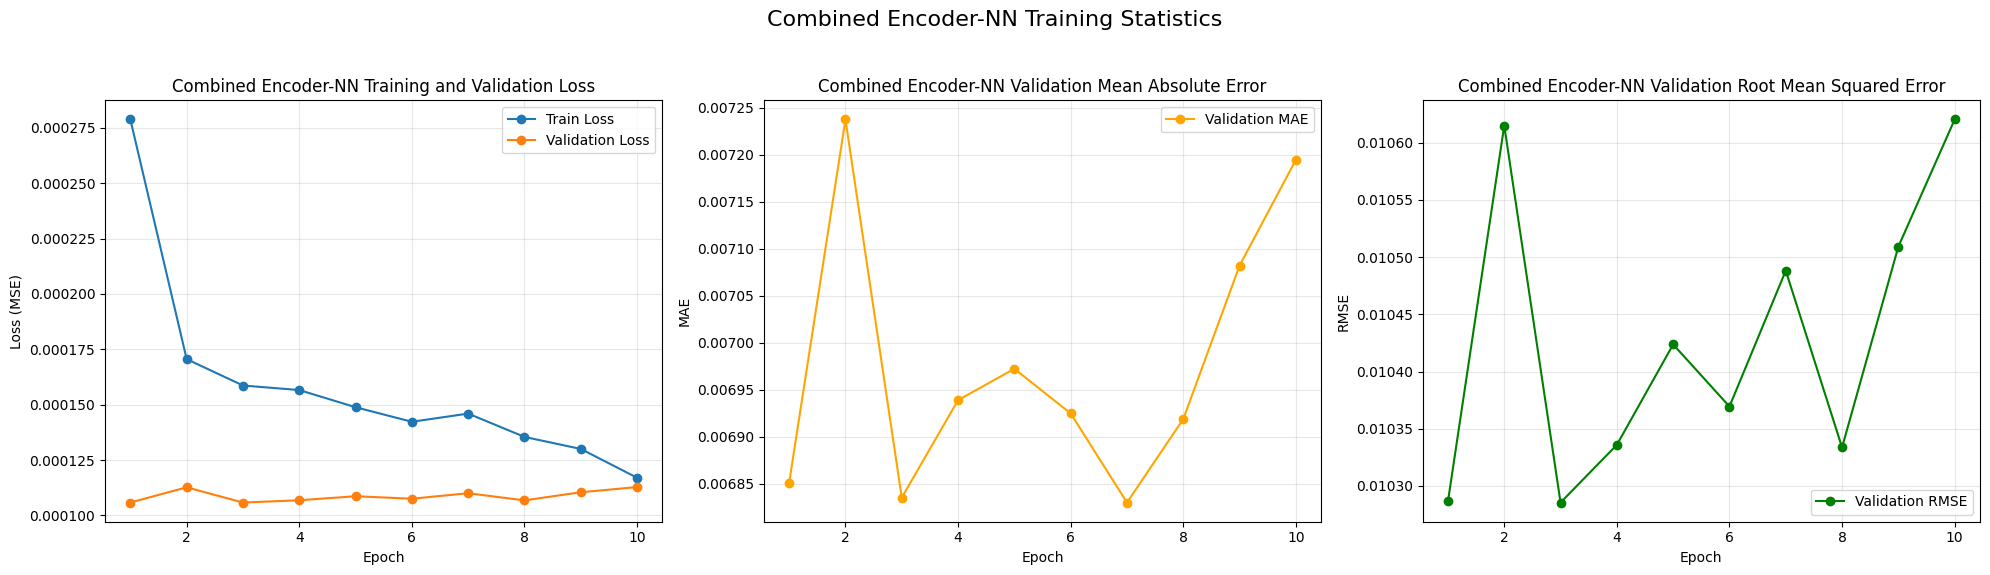

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming combined_encoder_nn_training_history DataFrame is available from the previous cell

if 'combined_encoder_nn_training_history' in globals() and not combined_encoder_nn_training_history.empty:
    plot_df_combined = combined_encoder_nn_training_history.copy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot Loss
    axes[0].plot(plot_df_combined['epoch'], plot_df_combined['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(plot_df_combined['epoch'], plot_df_combined['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title('Combined Encoder-NN Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Validation MAE
    axes[1].plot(plot_df_combined['epoch'], plot_df_combined['val_mae'], marker='o', color='orange', label='Validation MAE')
    axes[1].set_title('Combined Encoder-NN Validation Mean Absolute Error')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot Validation RMSE
    axes[2].plot(plot_df_combined['epoch'], plot_df_combined['val_rmse'], marker='o', color='green', label='Validation RMSE')
    axes[2].set_title('Combined Encoder-NN Validation Root Mean Squared Error')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('RMSE')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Combined Encoder-NN Training Statistics", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Combined Encoder-NN training history not found or is empty. Please ensure the model was trained successfully.")


## 2c. JSON-LLM, LoRA

we provide all the inputs together as raw-json text, and fine-tune an LLM using LoRA.

In [47]:
import json
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from types import SimpleNamespace
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    AutoConfig
)


def make_json_input(row):
    """Create a formatted prompt string for the LLM."""
    json_features = {}

    # Start with the text insight
    text_insight = str(row[TEXT_COLUMN]) if pd.notna(row[TEXT_COLUMN]) else "no insights"
    json_features[TEXT_COLUMN] = text_insight

    for column in FEATURE_COLUMNS:
        if column == TEXT_COLUMN:
            continue # Skip the text column as it's already used

        value = row[column]
        display_name = FEATURE_NAME_MAP.get(column, column) # Use mapped name or original

        if pd.isna(value):
            json_features[display_name] = None
        elif isinstance(value, np.generic): # Handle numpy types
            json_features[display_name] = value.item()
        else:
            json_features[display_name] = value


    # Format json_features into a pretty JSON string, indented for readability as per prompt example
    # The outer prompt already has { and } and newlines, so we only need the content of the JSON here
    json_content_lines = []
    for key, val in json_features.items():
        # Custom formatting to match the example's key: value structure without inner quotes for numbers
        if isinstance(val, (int, float)) and not pd.isna(val):
            json_content_lines.append(f"\t{key}: {val},")
        else:
            json_content_lines.append(f"\t{key}: {json.dumps(val, ensure_ascii=False)},")

    # Join and strip the last comma for the final JSON block
    json_block = "\n".join(json_content_lines).strip()
    if json_block.endswith(','):
        json_block = json_block[:-1]

    return f"{{\n{json_block}\n}}\n"


# Build examples using only rows with complete features and target values.
# Use the unique FEATURE_COLUMNS for consistency
EXTRA_COLUMNS = [TEXT_COLUMN, TARGET_COLUMN, SENTIMENT_COLUMN, SPLIT_COLUMN]
llm_columns = FEATURE_COLUMNS + EXTRA_COLUMNS
llm_data = articles[llm_columns].copy()
llm_data = llm_data.dropna(subset=EXTRA_COLUMNS)

print("Generating LLM input prompts...")
llm_data["text"] = llm_data.apply(make_json_input, axis=1)
llm_data["labels"] = llm_data[TARGET_COLUMN].astype("float32")
print("LLM input prompts generated.")

# Build prompts that match the eval / train needs
def enrich_train(row):
    row["text"] += f"The sentiment here is {row[SENTIMENT_COLUMN]} ({SENTIMENT_MAP[row[SENTIMENT_COLUMN]]})\n"
    return row

def enrich_eval(row):
    row["text"] += f"What is the sentiment? Answer with exactly one number with no extra characters whatsoeever, according to this index:\n"
    row["text"] += ", ".join(f"{k}: {v}" for k, v in SENTIMENT_MAP.items())
    return row

train_df = llm_data[llm_data[SPLIT_COLUMN] == "training"].apply(enrich_train, axis=1)
val_df = llm_data[llm_data[SPLIT_COLUMN] == "validation"].apply(enrich_eval, axis=1)
test_df = llm_data[llm_data[SPLIT_COLUMN] == "test"].apply(enrich_eval, axis=1)

def to_hf_dataset(dataframe):
    return Dataset.from_pandas(
        dataframe[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    )

train_dataset = to_hf_dataset(train_df)
val_dataset = to_hf_dataset(val_df)
test_dataset = to_hf_dataset(test_df)

# Print summary
print(f"Model: {JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE]}")
print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")

print("Tokenizing datasets...")

tokenizer = AutoTokenizer.from_pretrained(
    JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE],
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_examples(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=JSON_LLM_CONFIG.MAX_LENGTH,
    )

train_dataset = train_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
val_dataset = val_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
test_dataset = test_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
print("Datasets tokenized.")

model_name = JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE]

# Load model configuration first and modify it
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.num_labels = 1
config.problem_type = "regression"

# Ensure pad_token_id is set in the config before loading the model
# This check handles cases where tokenizer.pad_token might have been None initially.
if tokenizer.pad_token_id is not None:
    config.pad_token_id = tokenizer.pad_token_id
else:
    # Fallback, though tokenizer.pad_token should be set to eos_token by now
    config.pad_token_id = tokenizer.eos_token_id

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config, # Pass the modified config
    torch_dtype=torch.float32,
    trust_remote_code=True # Add trust_remote_code for robustness
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=JSON_LLM_CONFIG.LORA_ALPHA,
    lora_dropout=JSON_LLM_CONFIG.LORA_DROPOUT,
    target_modules="all-linear",
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
)


def compute_metrics(eval_prediction):
    predictions, labels = eval_prediction
    predictions = np.asarray(predictions).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    errors = predictions - labels
    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors ** 2))),
    }


training_args = TrainingArguments(
    output_dir=JSON_LLM_CONFIG.LLM_OUTPUT_DIR,
    learning_rate=JSON_LLM_CONFIG.TRAIN_LEARNING_RATE,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=JSON_LLM_CONFIG.TRAIN_EPOCHS,
    weight_decay=JSON_LLM_CONFIG.TRAIN_WEIGHTS_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting LLM training...")
lora_training_output = trainer.train()
print("LLM training complete.")

validation_metrics = trainer.evaluate(val_dataset)
test_metrics = trainer.evaluate(test_dataset)

print("Validation metrics:", validation_metrics)
print("Test metrics:", test_metrics)

trainer.save_model(JSON_LLM_CONFIG.LLM_OUTPUT_DIR)
tokenizer.save_pretrained(JSON_LLM_CONFIG.LLM_OUTPUT_DIR)
print(f"Saved LoRA model and tokenizer to: {JSON_LLM_CONFIG.LLM_OUTPUT_DIR}")

Generating LLM input prompts...
LLM input prompts generated.
Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Train: 3,165
Validation: 1,095
Test: 1,236
Tokenizing datasets...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Epoch,Training Loss,Validation Loss,Mae,Rmse
1,0.423789,0.282278,0.360067,0.531299
2,0.049586,0.043747,0.140152,0.209157
3,0.012638,0.012171,0.071324,0.110324
4,0.006172,0.007582,0.057570,0.087075
5,0.004683,0.005906,0.055097,0.076851
6,0.002237,0.001908,0.028936,0.043679
7,0.001439,0.002190,0.028842,0.046795
8,0.000773,0.002458,0.029237,0.049580
9,0.000625,0.002385,0.028337,0.048839
10,0.000604,0.002190,0.026300,0.046798


LLM training complete.


Training Loss,Validation Loss,Epoch,Mae,Rmse
0.000604,0.001908,10,0.028936,0.043679


Training Loss,Validation Loss,Epoch,Mae,Rmse
0.000604,0.001824,10,0.027412,0.042708


Validation metrics: {'eval_loss': 0.001907859230414033, 'eval_mae': 0.02893626131117344, 'eval_rmse': 0.043679047375917435}
Test metrics: {'eval_loss': 0.0018239981727674603, 'eval_mae': 0.027412211522459984, 'eval_rmse': 0.04270829260349274}
Saved LoRA model and tokenizer to: ./news_lora_model


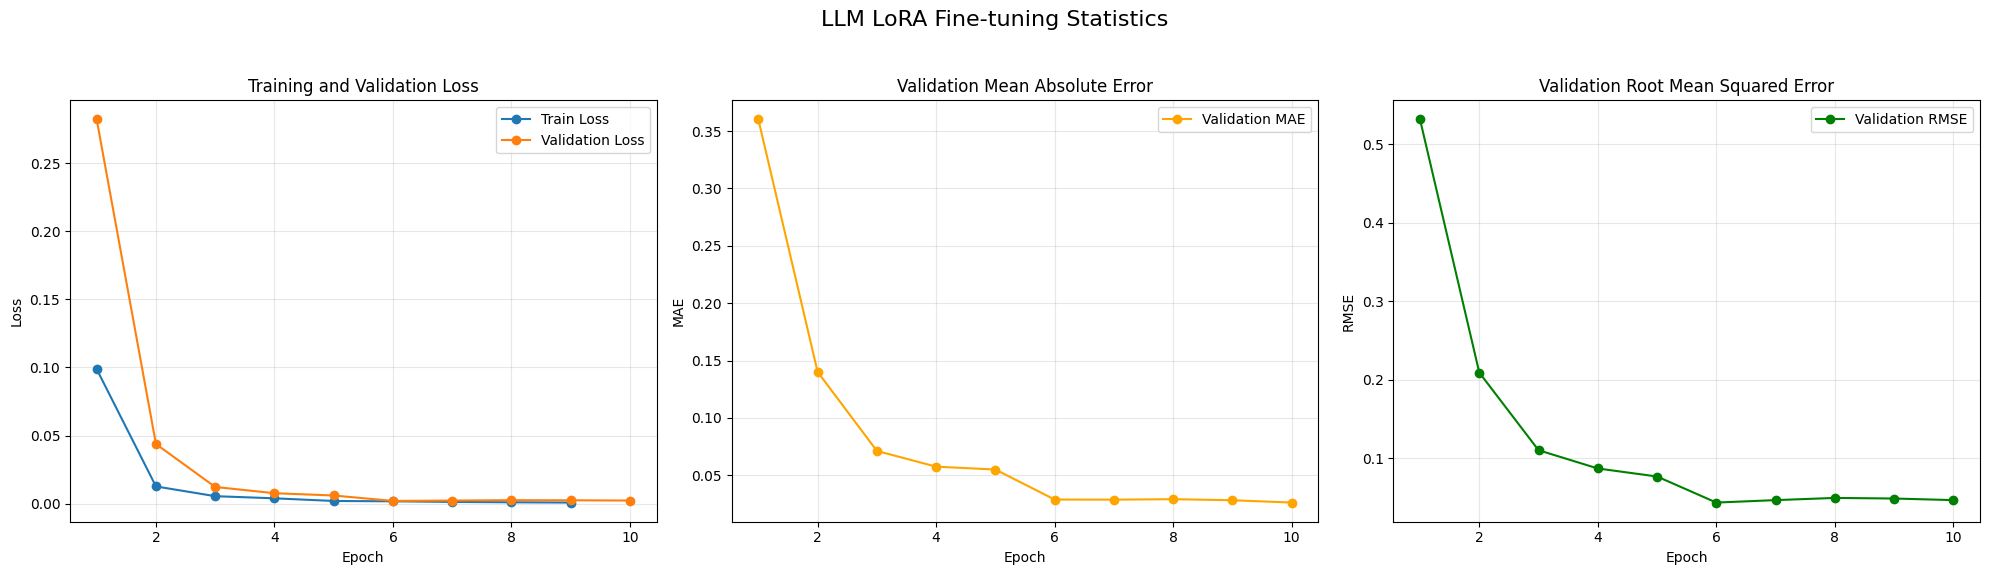


--- Final LLM LoRA Metrics ---
Validation Loss: 0.001908
Validation MAE: 0.028936
Validation RMSE: 0.043679
Test Loss: 0.001824
Test MAE: 0.027412
Test RMSE: 0.042708


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract training history from lora_training_output
log_history = trainer.state.log_history

# Separate training step logs and epoch-end evaluation logs
train_steps_logs = [entry for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
eval_epochs_logs = [entry for entry in log_history if 'eval_loss' in entry]

if not eval_epochs_logs:
    print("No epoch-wise evaluation metrics found in training log history.")
    print("\n--- Final LLM LoRA Metrics ---")
    print(f"Validation Loss: {validation_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Validation MAE: {validation_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Validation RMSE: {validation_metrics.get('eval_rmse', 'N/A'):.6f}")
    print(f"Test Loss: {test_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Test MAE: {test_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Test RMSE: {test_metrics.get('eval_rmse', 'N/A'):.6f}")
else:
    # Prepare data for plotting
    epochs = sorted(list(set(int(entry['epoch']) for entry in eval_epochs_logs)))

    train_losses = []
    val_losses = []
    val_maes = []
    val_rmses = []

    for epoch_num in epochs:
        # Get average training loss for this epoch
        current_epoch_train_losses = [
            entry['loss'] for entry in train_steps_logs
            if int(entry['epoch']) == epoch_num and entry['epoch'] >= epoch_num - 1 + 1e-6 # Ensure it's within this integer epoch
        ]
        if current_epoch_train_losses:
            train_losses.append(np.mean(current_epoch_train_losses))
        else:
            train_losses.append(np.nan) # Append NaN if no training loss logged for this epoch

        # Get validation metrics for this epoch
        epoch_eval_entry = next((entry for entry in eval_epochs_logs if int(entry['epoch']) == epoch_num), None)
        if epoch_eval_entry:
            val_losses.append(epoch_eval_entry['eval_loss'])
            val_maes.append(epoch_eval_entry['eval_mae'])
            val_rmses.append(epoch_eval_entry['eval_rmse'])
        else:
            val_losses.append(np.nan)
            val_maes.append(np.nan)
            val_rmses.append(np.nan)

    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'epoch': epochs,
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_mae': val_maes,
        'val_rmse': val_rmses
    })

    # Drop rows where all metrics are NaN (e.g., if an epoch had no logs or was skipped)
    plot_df = plot_df.dropna(subset=['train_loss', 'val_loss', 'val_mae', 'val_rmse'], how='all')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot Loss
    axes[0].plot(plot_df['epoch'], plot_df['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(plot_df['epoch'], plot_df['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Validation MAE
    axes[1].plot(plot_df['epoch'], plot_df['val_mae'], marker='o', color='orange', label='Validation MAE')
    axes[1].set_title('Validation Mean Absolute Error')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot Validation RMSE
    axes[2].plot(plot_df['epoch'], plot_df['val_rmse'], marker='o', color='green', label='Validation RMSE')
    axes[2].set_title('Validation Root Mean Squared Error')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('RMSE')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("LLM LoRA Fine-tuning Statistics", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

    # Display final metrics
    print("\n--- Final LLM LoRA Metrics ---")
    print(f"Validation Loss: {validation_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Validation MAE: {validation_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Validation RMSE: {validation_metrics.get('eval_rmse', 'N/A'):.6f}")
    print(f"Test Loss: {test_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Test MAE: {test_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Test RMSE: {test_metrics.get('eval_rmse', 'N/A'):.6f}")

## 2d. Text+Floats regressor — inlined

Same architecture as the packaged `model_shay`, written out in full below so this
notebook runs standalone (no repo checkout, no `pip install -e`).

```
consolidated_insights ──> DeBERTa-v3-base ──> mean-pool ──┐
float_1..3 (market)      ─────── standardized ────────────┤──> Linear(768+N,128) -> GELU -> Dropout -> Linear(128,1)
sentiment 1..5           ─────── one-hot (5) ─────────────┤
is_act_from_insights     ─────── one-hot (2) ─────────────┘
```

Four details below are load-bearing for the conclusions, and each is commented at
the point it appears:

1. **`.float()` on the encoder.** `deberta-v3-base` declares `torch_dtype: float16`
   and `transformers>=5` honours it, so the model loads with fp16 *parameters* and
   trains straight to NaN. Master weights must be fp32; mixed precision is
   autocast's job.
2. **Flat 512 padding**, with the 81 over-budget rows dropped rather than truncated.
3. **`GroupKFold` on `(ticker, trading-day)`.** 46% of rows share a ticker-day, so
   ungrouped folds split near-duplicate targets and inflate every metric.
4. **The target is standardized in training space.** Raw returns are ~0.01, so
   `HuberLoss(delta=1.0)` would never leave the quadratic region and `loss_type`
   would be a no-op. All metrics are inverse-transformed back to return units.

In [20]:
# ---------------------------------------------------------------------------
# Sections 2d-2f are SELF-CONTAINED: no repo, no model_shay / model_tree import.
# Section 0 already installed torch / transformers / peft; these are the extras.
# ---------------------------------------------------------------------------
%pip install -q "psycopg[binary]>=3.2" scikit-learn matplotlib joblib

import sys
IN_COLAB = "google.colab" in sys.modules
print("colab:", IN_COLAB)

colab: True


In [21]:
# ===========================================================================
# Config -- every knob for the inlined model. Mirrors model_shay/config.py.
# ===========================================================================
from dataclasses import dataclass, asdict, field
from pathlib import Path
import json, math, random, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Which DB columns fill float_1..3 and the target, per measurement window.
#   at_article  : everything measured at the article's minute
#   30m_before  : everything measured 30 min BEFORE it (first-ticker columns only)
WINDOW_COLUMNS = {
    "at_article": {
        "float_1": "vix_at_article_time",
        "float_2": "intraday_gain_till_article",
        "float_3": "aiq_ai_etf_intraday_gain_till_article",
        "gain_90m_after": "gain_90m_after_article",
        "intraday_gain_till": "intraday_gain_till_article",
    },
    "30m_before": {
        "float_1": "vix_intraday_gain_till_30m_before_article_first",
        "float_2": "intraday_gain_till_30m_before_article_first",
        "float_3": "aiq_ai_etf_intraday_gain_till_30m_before_article",
        "gain_90m_after": "intraday_gain_30m_before_to_90m_after_article_first",
        # the -30m -> article segment; NOT open->article, which correlates 0.95
        # with float_2 and would let the floats echo the answer.
        "intraday_gain_till": "intraday_gain_30m_before_till_article_first",
    },
}
_SUFFIXLESS = {"vix_at_article_time", "aiq_ai_etf_intraday_gain_till_article"}
SENTIMENT_CLASSES, ACT_CLASSES = 5, 2


@dataclass
class Cfg:
    # -- data --
    dsn: str | None = None
    window: str = "30m_before"          # at_article | 30m_before
    ticker_variant: str = "first"       # primary | first
    target_kind: str = "gain_90m_after" # gain_90m_after | intraday_gain_till
    text_column: str = "consolidated_insights"
    exclude_long_insights: bool = True      # drop rows over the 512-token budget
    exclude_first_market_30m: bool = True   # 30m window: drop first-half-hour articles
    act_filter: bool | None = None          # row filter on is_act_from_insights
    limit: int | None = None
    # -- dense inputs --
    use_floats: bool = True
    use_sentiment: bool = False         # 5-dim one-hot of articles.sentiment
    use_act: bool = False               # 2-dim one-hot of is_act_from_insights
    # -- text encoder --
    encoder_name: str = "microsoft/deberta-v3-base"
    max_length: int = 512
    pooling: str = "mean"               # mean | cls
    head_hidden_dim: int = 128
    head_dropout: float = 0.25
    # -- loss --
    loss_type: str = "huber"            # huber | mse
    huber_delta: float = 1.0
    # -- optimisation --
    train_mode: str = "partial_freeze"  # partial_freeze | lora
    freeze_except_last_n: int = 3
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.1
    head_lr: float = 1e-3
    encoder_lr: float = 2e-5
    phase2_min_lr: float = 5e-6
    phase1_epochs: int = 4
    unfreeze_all_phase2: bool = False   # phase 2 hurt in every run we made
    weight_decay: float = 0.01
    warmup_ratio: float = 0.06
    max_grad_norm: float = 1.0
    batch_size: int = 32
    grad_accum: int = 1
    max_epochs: int = 20
    gradient_checkpointing: bool = True # without it phase 2 OOMs on a 16GB card
    patience: int = 3
    seed: int = 42
    k_folds: int = 5

    def __post_init__(self):
        if self.window == "30m_before":
            self.ticker_variant = "first"   # only the _first columns were computed
        if self.use_floats and self.col("float_2") == self.target_column:
            raise ValueError(f"float_2 IS the target ({self.target_column}) -- "
                             "set use_floats=False for this target_kind.")

    def col(self, role: str) -> str:
        name = WINDOW_COLUMNS[self.window][role]
        if (self.window != "at_article" or self.ticker_variant == "primary"
                or name in _SUFFIXLESS):
            return name
        return name + "_first"

    @property
    def float_columns(self):  return tuple(self.col(f"float_{i}") for i in (1, 2, 3))
    @property
    def target_column(self):  return self.col(self.target_kind)
    @property
    def n_dense_features(self):
        return ((3 if self.use_floats else 0)
                + (SENTIMENT_CLASSES if self.use_sentiment else 0)
                + (ACT_CLASSES if self.use_act else 0))


# --- database ---------------------------------------------------------------
# Section 1a defines DATABASE_URL when DATA_SOURCE == "local_postgres". Reuse it,
# converting the SQLAlchemy URL to a plain psycopg DSN.
# Two sources, matching section 1a:
#   DATA_SOURCE == "online_csv"     -> reuse the `articles` DataFrame already in
#                                      memory (no database needed -- this is the
#                                      Colab path).
#   DATA_SOURCE == "local_postgres" -> query the DB through the DATABASE_URL that
#                                      section 1a built, converted to a psycopg DSN.
USE_CSV = globals().get("DATA_SOURCE") == "online_csv"
SHAY_DSN = None
if not USE_CSV:
    try:
        SHAY_DSN = DATABASE_URL.replace("+psycopg", "")
    except NameError:
        raise NameError("DATA_SOURCE is not 'online_csv' and DATABASE_URL is undefined -- "
                        "run section 1a first, or set DATA_SOURCE = 'online_csv'.")
if USE_CSV and "articles" not in globals():
    raise NameError("DATA_SOURCE == 'online_csv' but `articles` is not loaded -- "
                    "run section 1a first.")

print("DATA_SOURCE :", globals().get("DATA_SOURCE", "(unset)"))
print("source      :", "in-memory `articles` DataFrame" if USE_CSV else SHAY_DSN)

cfg = Cfg(dsn=SHAY_DSN, window="30m_before", use_sentiment=True, use_act=True)
print("target      :", cfg.target_column)
print("floats      :", list(cfg.float_columns))
print("dense width :", cfg.n_dense_features, "(3 floats + 5 sentiment + 2 act)")

DATA_SOURCE : online_csv
source      : in-memory `articles` DataFrame
target      : intraday_gain_30m_before_to_90m_after_article_first
floats      : ['vix_intraday_gain_till_30m_before_article_first', 'intraday_gain_till_30m_before_article_first', 'aiq_ai_etf_intraday_gain_till_30m_before_article']
dense width : 10 (3 floats + 5 sentiment + 2 act)


In [22]:
# ===========================================================================
# Data: load, filter, split, group. Mirrors model_shay/data.py.
# ===========================================================================
import psycopg

FLOAT_COLUMNS = ["float_1", "float_2", "float_3"]
MODEL_SETS = ("training", "validation", "test")

QUERY = """
SELECT id,
       {text_column}                                          AS text,
       {float_1} AS float_1, {float_2} AS float_2, {float_3} AS float_3,
       {target}                                               AS target,
       COALESCE(first_mentioned_ticker, first_listed_ticker)  AS ticker,
       (published_utc AT TIME ZONE 'America/New_York')::date  AS et_date,
       model_set, test_unseen, is_act_from_insights, sentiment
FROM public.articles
WHERE {where}
ORDER BY id
"""


_BOOL_MAP = {True: True, False: False, "t": True, "f": False, "T": True, "F": False,
             "true": True, "false": False, "True": True, "False": False,
             "TRUE": True, "FALSE": False, 1: True, 0: False, "1": True, "0": False}


def _as_bool(series, n):
    """Postgres CSV writes booleans as 't'/'f'; pandas writes True/False; some
    exports use 1/0. Normalise all of them, treating NULL and an absent column
    as False -- the COALESCE(..., false) of the SQL path.

    `.where` rather than `.fillna` keeps pandas from emitting the object-dtype
    downcasting FutureWarning.
    """
    if series is None:
        return pd.Series(False, index=range(n))
    m = series.map(_BOOL_MAP)
    return m.where(m.notna(), False).astype(bool)


def load_frame_from_df(cfg: Cfg, articles: pd.DataFrame,
                       require_target: bool = True) -> pd.DataFrame:
    """Same rows the SQL path returns, built from the CSV DataFrame instead.

    Every filter below mirrors load_frame_from_db one-for-one.
    """
    f1, f2, f3 = cfg.float_columns
    needed = [cfg.text_column, f1, f2, f3, "model_set", "published_utc"]
    if require_target:
        needed.append(cfg.target_column)
    missing = [c for c in needed if c not in articles.columns]
    if missing:
        raise KeyError(
            f"the CSV is missing {missing}. It predates these columns -- re-export "
            f"public.articles, or switch to DATA_SOURCE = 'local_postgres'.")

    a = articles
    n = len(a)
    et = (pd.to_datetime(a["published_utc"], utc=True, errors="coerce")
            .dt.tz_convert("America/New_York"))
    ticker = a["first_mentioned_ticker"] if "first_mentioned_ticker" in a else pd.Series(None, index=a.index)
    if "first_listed_ticker" in a:
        ticker = ticker.fillna(a["first_listed_ticker"])

    d = pd.DataFrame({
        "id": a["id"] if "id" in a else np.arange(n),
        "text": a[cfg.text_column],
        "float_1": a[f1], "float_2": a[f2], "float_3": a[f3],
        "target": a[cfg.target_column] if require_target else np.nan,
        "ticker": ticker, "et_date": et.dt.date, "model_set": a["model_set"],
        "test_unseen": a["test_unseen"] if "test_unseen" in a else None,
        "is_act_from_insights": a["is_act_from_insights"] if "is_act_from_insights" in a else None,
        "sentiment": a["sentiment"] if "sentiment" in a else None,
    })

    keep = d["text"].notna() & et.notna() & d["model_set"].isin(MODEL_SETS)
    keep &= d[["float_1", "float_2", "float_3"]].notna().all(axis=1)
    if require_target:
        keep &= d["target"].notna()
    if cfg.exclude_long_insights:
        keep &= ~_as_bool(a.get("insights_too_long_more_than_500"), n).to_numpy()
    if cfg.use_sentiment:
        keep &= d["sentiment"].notna()
    if cfg.use_act:
        keep &= d["is_act_from_insights"].notna()
    if cfg.act_filter is not None:
        keep &= _as_bool(a.get("is_act_from_insights"), n).to_numpy() == bool(cfg.act_filter)
    if cfg.window == "30m_before" and cfg.exclude_first_market_30m:
        keep &= ~_as_bool(a.get("article_in_first_market_30m"), n).to_numpy()

    d = d[keep].reset_index(drop=True)
    # Coerce AFTER filtering: the notna() checks above need the raw NULLs, but
    # everything downstream wants real bools/ints, not 't'/'f' strings.
    d["is_act_from_insights"] = _as_bool(d["is_act_from_insights"], len(d))
    d["test_unseen"] = _as_bool(d["test_unseen"], len(d))
    d["sentiment"] = pd.to_numeric(d["sentiment"], errors="coerce")
    for c in ("float_1", "float_2", "float_3", "target"):
        d[c] = pd.to_numeric(d[c], errors="coerce")
    return d


def load_frame_from_db(cfg: Cfg, require_target: bool = True) -> pd.DataFrame:
    f1, f2, f3 = cfg.float_columns
    where = [f"{cfg.text_column} IS NOT NULL", "published_utc IS NOT NULL",
             f"{f1} IS NOT NULL", f"{f2} IS NOT NULL", f"{f3} IS NOT NULL",
             "model_set IS NOT NULL"]
    if require_target:
        where.append(f"{cfg.target_column} IS NOT NULL")
    if cfg.exclude_long_insights:
        # The 81 rows over 500 tokens are DROPPED, not truncated, so nothing
        # silently loses content at the 512 ceiling.
        where.append("NOT COALESCE(insights_too_long_more_than_500, false)")
    if cfg.use_sentiment:
        where.append("sentiment IS NOT NULL")
    if cfg.use_act:
        where.append("is_act_from_insights IS NOT NULL")
    if cfg.act_filter is not None:
        where.append(f"is_act_from_insights IS {'TRUE' if cfg.act_filter else 'FALSE'}")
    if cfg.window == "30m_before" and cfg.exclude_first_market_30m:
        # their -30m anchor is clamped to the open, so the window is shorter
        where.append("NOT COALESCE(article_in_first_market_30m, false)")

    sql = QUERY.format(text_column=cfg.text_column, float_1=f1, float_2=f2, float_3=f3,
                       target=cfg.target_column, where=" AND ".join(where))
    with psycopg.connect(cfg.dsn) as conn, conn.cursor() as cur:
        cur.execute(sql)
        df = pd.DataFrame(cur.fetchall(), columns=[d.name for d in cur.description])
    return df.dropna(subset=FLOAT_COLUMNS + ["text"]
                     + (["target"] if require_target else [])).reset_index(drop=True)


def load_frame(cfg: Cfg, require_target: bool = True,
               articles_df: "pd.DataFrame | None" = None) -> pd.DataFrame:
    """Dispatch on DATA_SOURCE: the in-memory CSV DataFrame, or the database."""
    use_csv = globals().get("USE_CSV", False)
    if articles_df is None and use_csv:
        articles_df = globals().get("articles")
    if articles_df is not None:
        df = load_frame_from_df(cfg, articles_df, require_target)
        origin = "csv"
    else:
        df = load_frame_from_db(cfg, require_target)
        origin = "db"
    # The GroupKFold key. Rows sharing it must never straddle a fold: two
    # articles on the same name minutes apart have near-identical targets.
    df["group"] = df["ticker"].astype(str) + "|" + df["et_date"].astype(str)
    if cfg.limit:
        df = df.head(int(cfg.limit)).reset_index(drop=True)
    print(f"[data] {len(df)} rows ({origin}) | target={cfg.target_column}")
    return df


def split_frames(df):
    out = {k: df[df.model_set == k].reset_index(drop=True) for k in MODEL_SETS}
    print("[split] " + "  ".join(f"{k}={len(v)}" for k, v in out.items()))
    return out

In [23]:
# ===========================================================================
# Feature building, target transform, metrics. Fitted on the TRAIN FOLD ONLY.
# ===========================================================================
@dataclass
class FloatScaler:
    mean: list; scale: list

    @classmethod
    def fit(cls, x):
        x = np.asarray(x, float)
        s = x.std(0); s[s == 0] = 1.0
        return cls(x.mean(0).tolist(), s.tolist())

    def transform(self, x):
        return ((np.asarray(x, float) - self.mean) / np.array(self.scale)).astype(np.float32)


def _onehot(codes, n):
    out = np.zeros((len(codes), n), dtype=np.float32)
    ok = (codes >= 0) & (codes < n)
    out[np.flatnonzero(ok), codes[ok]] = 1.0
    return out


def build_features(df, cfg, scaler):
    """Dense vector appended to the pooled text. One-hots are NOT standardized:
    they are already on the right scale and centering would smear the classes."""
    parts = []
    if cfg.use_floats:
        parts.append(scaler.transform(df[FLOAT_COLUMNS].to_numpy()))
    if cfg.use_sentiment:
        sent = pd.to_numeric(df["sentiment"], errors="coerce").fillna(0).astype(np.int64)
        parts.append(_onehot(sent.to_numpy() - 1, SENTIMENT_CLASSES))
    if cfg.use_act:
        # _as_bool, not .astype(int): a CSV-sourced frame may still hold 't'/'f'.
        act = _as_bool(df["is_act_from_insights"], len(df)).to_numpy().astype(np.int64)
        parts.append(_onehot(act, ACT_CLASSES))
    if not parts:
        return np.zeros((len(df), 0), dtype=np.float32)
    return np.concatenate(parts, 1).astype(np.float32)


@dataclass
class TargetTransform:
    """Standardizes the target in TRAINING space only.

    Without this the raw target is a ~1% return, so HuberLoss(delta=1.0) keeps
    every residual inside the quadratic region and silently degenerates to MSE,
    making loss_type a no-op. Metrics are always inverse-transformed back to
    return units so they stay comparable across settings.
    """
    mean: float = 0.0; std: float = 1.0

    @classmethod
    def fit(cls, y):
        y = np.asarray(y, float)
        return cls(float(y.mean()), float(y.std()) or 1.0)

    def apply(self, y):   return ((np.asarray(y, float) - self.mean) / self.std).astype(np.float32)
    def inverse(self, z): return np.asarray(z, float) * self.std + self.mean


def regression_metrics(y_true, y_pred):
    err = np.asarray(y_pred, float) - np.asarray(y_true, float)
    mse, mae = float((err ** 2).mean()), float(np.abs(err).mean())
    var = float(np.var(y_true))
    return {"mse": mse, "rmse": math.sqrt(mse), "mae": mae, "mae_bps": mae * 1e4,
            "r2": (1 - mse / var) if var > 0 else float("nan")}

In [24]:
# ===========================================================================
# Model: DeBERTa encoder + dense vector -> scalar. Mirrors model_shay/model.py.
# ===========================================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup


class TextFloatsRegressor(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        self.pooling = cfg.pooling
        encoder = AutoModel.from_pretrained(cfg.encoder_name)
        # .float() is NOT redundant. deberta-v3-base's config declares
        # torch_dtype: float16 and transformers>=5 defaults dtype="auto", so it
        # loads fp16 PARAMETERS -- which train to NaN on the very first step
        # (AdamW moments and LayerNorm overflow in fp16). Master weights stay
        # fp32; mixed precision is autocast's job, not the weights'.
        self.encoder = encoder.float()
        self.n_features = cfg.n_dense_features
        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(h + self.n_features, cfg.head_hidden_dim), nn.GELU(),
            nn.Dropout(cfg.head_dropout), nn.Linear(cfg.head_hidden_dim, 1))

    def pool(self, hidden, mask):
        if self.pooling == "cls":
            return hidden[:, 0]
        # With flat 512 padding most positions are PAD, so masking is essential.
        m = mask.unsqueeze(-1).to(hidden.dtype)
        return (hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, feats):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(out.last_hidden_state, attention_mask)
        if self.n_features:
            pooled = torch.cat([pooled, feats.to(pooled.dtype)], -1)
        return self.head(pooled).squeeze(-1)


def build_loss(cfg):
    return nn.MSELoss() if cfg.loss_type == "mse" else nn.HuberLoss(delta=cfg.huber_delta)


def encoder_layers(enc):
    for path in ("encoder.layer", "encoder.layers", "layers"):
        obj = enc
        for part in path.split("."):
            obj = getattr(obj, part, None)
            if obj is None: break
        if isinstance(obj, nn.ModuleList): return obj
    raise RuntimeError("cannot locate encoder layers")


def apply_partial_freeze(model, last_n):
    for p in model.encoder.parameters(): p.requires_grad_(False)
    layers = encoder_layers(model.encoder)
    for layer in layers[len(layers) - last_n:]:
        for p in layer.parameters(): p.requires_grad_(True)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[freeze] last {last_n}/{len(layers)} block(s) + head trainable ({n/1e6:.1f}M)")


def apply_lora(model, cfg):
    from peft import LoraConfig, get_peft_model
    names = {n.rsplit(".", 1)[-1] for n, _ in model.encoder.named_modules()}
    targets = next(c for c in (["query_proj", "value_proj"], ["query", "value"])
                   if set(c) <= names)
    model.encoder = get_peft_model(model.encoder, LoraConfig(
        r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
        bias="none", target_modules=targets))
    for p in model.head.parameters(): p.requires_grad_(True)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[lora] r={cfg.lora_r} on {targets} ({n/1e6:.2f}M trainable)")


def prepare(model, cfg):
    apply_lora(model, cfg) if cfg.train_mode == "lora" else \
        apply_partial_freeze(model, cfg.freeze_except_last_n)


def make_dataset(df, tok, cfg, scaler, target_tf):
    # padding="max_length": every batch is a flat 512-token block, so memory is
    # constant across steps rather than a per-batch gamble.
    enc = tok(list(df["text"]), max_length=cfg.max_length, truncation=True,
              padding="max_length", return_tensors="pt")
    feats = torch.from_numpy(build_features(df, cfg, scaler))
    y = torch.from_numpy(target_tf.apply(df["target"].to_numpy())) \
        if target_tf is not None else torch.zeros(len(df))
    return TensorDataset(enc["input_ids"], enc["attention_mask"], feats, y)

In [25]:
# ===========================================================================
# Training loop: two phases, early stopping, AMP. Mirrors model_shay/train.py.
# ===========================================================================
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


def pick_precision(device):
    if device.type != "cuda": return None, False
    if torch.cuda.is_bf16_supported(): return torch.bfloat16, False
    return torch.float16, True


class BestTracker:
    """Early stopping: lowest val loss wins, best weights kept in RAM."""
    def __init__(self, patience):
        self.patience, self.best, self.best_epoch = patience, math.inf, -1
        self.state, self.stale = None, 0

    def update(self, epoch, value, model):
        if value < self.best - 1e-12:
            self.best, self.best_epoch, self.stale = value, epoch, 0
            self.state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return True
        self.stale += 1
        return False

    @property
    def should_stop(self): return self.stale >= self.patience
    def restore(self, model):
        if self.state is not None: model.load_state_dict(self.state)


@torch.no_grad()
def evaluate(model, loader, loss_fn, target_tf, device, amp):
    model.eval(); total = n = 0; preds, trues = [], []
    for ids, mask, feats, y in loader:
        ids, mask, feats, y = ids.to(device), mask.to(device), feats.to(device), y.to(device)
        with torch.autocast("cuda", dtype=amp, enabled=amp is not None):
            out = model(ids, mask, feats); loss = loss_fn(out.float(), y)
        total += float(loss) * y.size(0); n += y.size(0)
        preds.append(out.float().cpu().numpy()); trues.append(y.float().cpu().numpy())
    # Metrics always in RETURN UNITS, never training space.
    p, t = target_tf.inverse(np.concatenate(preds)), target_tf.inverse(np.concatenate(trues))
    return total / max(n, 1), regression_metrics(t, p), p


def optimizer_for(groups, cfg, model):
    no_decay = {id(p) for p in model.parameters() if p.ndim <= 1}
    split = []
    for g in groups:
        ps = [p for p in g["params"] if p.requires_grad]
        decay = [p for p in ps if id(p) not in no_decay]
        plain = [p for p in ps if id(p) in no_decay]
        if decay: split.append({"params": decay, "lr": g["lr"], "weight_decay": cfg.weight_decay})
        if plain: split.append({"params": plain, "lr": g["lr"], "weight_decay": 0.0})
    return torch.optim.AdamW(split)


def run_phase(model, cfg, tr_loader, va_loader, loss_fn, target_tf, device,
              groups, n_epochs, tracker, tag, amp, use_scaler, offset=0):
    if n_epochs <= 0: return 0
    opt = optimizer_for(groups, cfg, model)
    steps = max(1, math.ceil(len(tr_loader) / cfg.grad_accum)) * n_epochs
    sched = get_linear_schedule_with_warmup(opt, int(steps * cfg.warmup_ratio), steps)
    gscaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
    ran = 0
    for epoch in range(1, n_epochs + 1):
        model.train(); t0, run, seen = time.monotonic(), 0.0, 0
        opt.zero_grad(set_to_none=True)
        for step, (ids, mask, feats, y) in enumerate(tr_loader, 1):
            ids, mask, feats, y = ids.to(device), mask.to(device), feats.to(device), y.to(device)
            with torch.autocast("cuda", dtype=amp, enabled=amp is not None):
                loss = loss_fn(model(ids, mask, feats).float(), y)
            if not torch.isfinite(loss):
                raise SystemExit(f"non-finite loss at epoch {epoch} step {step}: check that "
                                 f"the encoder holds fp32 weights "
                                 f"({next(model.encoder.parameters()).dtype})")
            gscaler.scale(loss / cfg.grad_accum).backward()
            run += float(loss) * y.size(0); seen += y.size(0)
            if step % cfg.grad_accum == 0 or step == len(tr_loader):
                gscaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in opt.param_groups for p in g["params"]], cfg.max_grad_norm)
                gscaler.step(opt); gscaler.update()
                opt.zero_grad(set_to_none=True); sched.step()
        vl, m, _ = evaluate(model, va_loader, loss_fn, target_tf, device, amp)
        e = offset + epoch
        star = " *" if tracker.update(e, vl, model) else ""
        print(f"[{tag} e{e:02d}] train={run/max(seen,1):.5f} val={vl:.5f} "
              f"mae={m['mae_bps']:.1f}bps r2={m['r2']:+.4f} ({time.monotonic()-t0:.0f}s){star}")
        ran += 1
        if tracker.should_stop:
            print(f"[{tag}] early stop; best val={tracker.best:.5f} @ e{tracker.best_epoch}")
            break
    return ran


def train_one(cfg, train_df, val_df, tok, tag="single"):
    set_seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    amp, use_scaler = pick_precision(device)

    # Both transforms fitted on the TRAINING FOLD ONLY -- no leakage.
    scaler = FloatScaler.fit(train_df[FLOAT_COLUMNS].to_numpy())
    target_tf = TargetTransform.fit(train_df["target"].to_numpy())

    tr = DataLoader(make_dataset(train_df, tok, cfg, scaler, target_tf),
                    batch_size=cfg.batch_size, shuffle=True)
    va = DataLoader(make_dataset(val_df, tok, cfg, scaler, target_tf),
                    batch_size=cfg.batch_size)

    model = TextFloatsRegressor(cfg).to(device)
    prepare(model, cfg)
    if cfg.gradient_checkpointing:
        # use_reentrant=False: the reentrant variant errors when part of the
        # encoder is frozen, which is exactly phase 1.
        model.encoder.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={"use_reentrant": False})
    loss_fn, tracker = build_loss(cfg), BestTracker(cfg.patience)
    print(f"[{tag}] train={len(train_df)} val={len(val_df)} device={device} "
          f"loss={cfg.loss_type} mode={cfg.train_mode}")

    head = [p for p in model.head.parameters() if p.requires_grad]
    enc = [p for p in model.encoder.parameters() if p.requires_grad]
    groups = [{"params": head, "lr": cfg.head_lr}] + ([{"params": enc, "lr": cfg.encoder_lr}] if enc else [])

    two_phase = cfg.train_mode == "partial_freeze" and cfg.unfreeze_all_phase2
    n1 = min(cfg.phase1_epochs, cfg.max_epochs) if two_phase else cfg.max_epochs
    done = run_phase(model, cfg, tr, va, loss_fn, target_tf, device, groups, n1,
                     tracker, f"{tag}/p1", amp, use_scaler)

    if two_phase and not tracker.should_stop:
        for p in model.encoder.parameters(): p.requires_grad_(True)
        layers = encoder_layers(model.encoder); n = len(layers)
        ids_ = {id(p) for l in layers for p in l.parameters()}
        g2 = [{"params": list(model.head.parameters()), "lr": cfg.head_lr}]
        for i, l in enumerate(layers):
            lr = cfg.phase2_min_lr + (i / max(n - 1, 1)) * (cfg.encoder_lr - cfg.phase2_min_lr)
            g2.append({"params": list(l.parameters()), "lr": lr})
        rest = [p for p in model.encoder.parameters() if id(p) not in ids_]
        if rest: g2.append({"params": rest, "lr": cfg.phase2_min_lr})
        tracker.stale = 0
        run_phase(model, cfg, tr, va, loss_fn, target_tf, device, g2,
                  cfg.max_epochs - done, tracker, f"{tag}/p2", amp, use_scaler, done)

    tracker.restore(model)
    vl, m, _ = evaluate(model, va, loss_fn, target_tf, device, amp)
    print(f"[{tag}] best @ e{tracker.best_epoch} :: mae={m['mae_bps']:.1f}bps r2={m['r2']:+.4f}")
    return {"tag": tag, **m, "val_loss": vl, "best_epoch": tracker.best_epoch,
            "n_train": len(train_df), "n_val": len(val_df),
            "model": model, "scaler": scaler, "target_tf": target_tf}

In [26]:
# ===========================================================================
# Single split and GroupKFold CV.
# ===========================================================================
from sklearn.model_selection import GroupKFold


def run_single(cfg, eval_test=True):
    df = load_frame(cfg); sp = split_frames(df)
    tok = AutoTokenizer.from_pretrained(cfg.encoder_name)
    res = train_one(cfg, sp["training"], sp["validation"], tok, "single")
    if eval_test and len(sp["test"]):
        ds = make_dataset(sp["test"], tok, cfg, res["scaler"], res["target_tf"])
        dl = DataLoader(ds, batch_size=cfg.batch_size)
        device = next(res["model"].parameters()).device
        amp, _ = pick_precision(device)
        _, m, _ = evaluate(res["model"], dl, build_loss(cfg), res["target_tf"], device, amp)
        print(f"[test] n={len(sp['test'])} mae={m['mae_bps']:.1f}bps r2={m['r2']:+.4f}")
        res["test"] = m
    return res


def run_kfold(cfg):
    """GroupKFold on (ticker, trading-day) -- mandatory, not optional.

    46% of the corpus shares a ticker-day with another row (largest cluster 30).
    Plain KFold would put near-duplicate targets on both sides of the boundary
    and inflate every metric.
    """
    df = load_frame(cfg); sp = split_frames(df)
    pool = pd.concat([sp["training"], sp["validation"]], ignore_index=True)
    groups = pool["group"].to_numpy()
    tok = AutoTokenizer.from_pretrained(cfg.encoder_name)
    print(f"[kfold] {len(pool)} rows / {len(set(groups))} groups, k={cfg.k_folds}")
    folds = []
    for i, (tr, va) in enumerate(GroupKFold(n_splits=cfg.k_folds).split(pool, groups=groups), 1):
        r = train_one(cfg, pool.iloc[tr].reset_index(drop=True),
                      pool.iloc[va].reset_index(drop=True), tok, f"fold_{i}")
        folds.append({k: v for k, v in r.items() if k not in ("model", "scaler", "target_tf")})
    out = pd.DataFrame(folds)
    print("\n" + out[["tag", "val_loss", "mae_bps", "r2", "best_epoch"]].to_string(index=False))
    print(f"\nR2 = {out.r2.mean():+.4f} +- {out.r2.std():.4f}")
    return out

### 2d (i) The corpus, and why grouping is mandatory

In [27]:
df = load_frame(cfg)
splits = split_frames(df)

vc = df["group"].value_counts()
clustered = int(vc[vc > 1].sum())
print(f"\nrows sharing a (ticker, trading-day) with another row: "
      f"{clustered}/{len(df)} = {clustered/len(df):.0%}")
print(f"largest cluster: {vc.max()} articles | distinct groups: {df['group'].nunique()}")

y = df["target"]
print(f"\ntarget: mean={y.mean():+.6f}  sd={y.std():.6f}  "
      f"p1={y.quantile(.01):+.4f}  p99={y.quantile(.99):+.4f}")
print(f"=> sd is ~{y.std()*1e4:.0f} bps. Compare models on R2, not MAE in bps.")

[data] 5034 rows (csv) | target=intraday_gain_30m_before_to_90m_after_article_first
[split] training=2905  validation=1002  test=1127

rows sharing a (ticker, trading-day) with another row: 2235/5034 = 44%
largest cluster: 29 articles | distinct groups: 3640

target: mean=+0.000094  sd=0.013570  p1=-0.0407  p99=+0.0370
=> sd is ~136 bps. Compare models on R2, not MAE in bps.


### 2d (ii) Train

`LIMIT` keeps the demo quick. Set it to `None` to reproduce the numbers in the
evaluation section — the full corpus takes roughly 20 minutes per run on a 16GB GPU.

Phase 2 (full-encoder unfreeze) is off: it degraded validation in every run.
Gradient checkpointing is on — without it, phase 2 needs 12.6 GiB at batch 16 and
OOMs at batch 32 on a 16GB card.

In [28]:
LIMIT = 500          # None = full corpus (~20 min/run on a 16GB GPU)

train_cfg = Cfg(dsn=SHAY_DSN, window="30m_before",
                use_sentiment=True, use_act=True,
                unfreeze_all_phase2=False, batch_size=32, limit=LIMIT)
result = run_single(train_cfg, eval_test=True)

# GroupKFold instead (5 folds, ~5x the time):
# folds = run_kfold(Cfg(dsn=SHAY_DSN, window="30m_before", use_sentiment=True,
#                       use_act=True, unfreeze_all_phase2=False, batch_size=32))

[data] 500 rows (csv) | target=intraday_gain_30m_before_to_90m_after_article_first
[split] training=301  validation=91  test=108


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

[freeze] last 3/12 block(s) + head trainable (21.4M)
[single] train=301 val=91 device=cuda loss=huber mode=partial_freeze


/tmp/ipykernel_591/777462061.py:80: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  run += float(loss) * y.size(0); seen += y.size(0)


[single/p1 e01] train=0.29324 val=0.21650 mae=79.7bps r2=-0.0515 (8s) *
[single/p1 e02] train=0.29389 val=0.22717 mae=82.4bps r2=-0.1078 (5s)
[single/p1 e03] train=0.28025 val=0.23622 mae=84.6bps r2=-0.1418 (5s)
[single/p1 e04] train=0.32809 val=0.25115 mae=87.8bps r2=-0.2401 (5s)
[single/p1] early stop; best val=0.21650 @ e1
[single] best @ e1 :: mae=79.7bps r2=-0.0515
[test] n=108 mae=92.4bps r2=-0.0127


## 2e. Tree on the dense vector only — inlined

The control for *how much the text actually adds*: same corpus, same splits, same
`GroupKFold`, same metric code — but the input is only the 10-dim dense vector, with
no encoder at all.

In [29]:
# ===========================================================================
# model_tree, inlined: GBDT on the dense vector only -- no text encoder.
# The gap between this and section 2d is what the text actually contributes.
# ===========================================================================
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance


def feature_names(cfg):
    names = []
    if cfg.use_floats:    names += list(cfg.float_columns)
    if cfg.use_sentiment: names += [f"sentiment_{i}" for i in range(1, 6)]
    if cfg.use_act:       names += ["act_false", "act_true"]
    return names


def run_tree(cfg, max_iter=400, learning_rate=0.05, max_depth=None,
             min_samples_leaf=20, seed=42):
    df = load_frame(cfg); sp = split_frames(df)
    names = feature_names(cfg)
    print(f"[tree] hgb on {len(names)} feature(s)")
    pool = pd.concat([sp["training"], sp["validation"]], ignore_index=True)
    groups = pool["group"].to_numpy()

    rows, est, scaler = [], None, None
    for i, (tr, va) in enumerate(GroupKFold(n_splits=cfg.k_folds).split(pool, groups=groups), 1):
        train, val = pool.iloc[tr], pool.iloc[va]
        scaler = FloatScaler.fit(train[FLOAT_COLUMNS].to_numpy())
        xt, yt = build_features(train, cfg, scaler), train["target"].to_numpy()
        xv, yv = build_features(val, cfg, scaler), val["target"].to_numpy()
        est = HistGradientBoostingRegressor(
            max_iter=max_iter, learning_rate=learning_rate, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, early_stopping="auto",
            random_state=seed).fit(xt, yt)
        m = regression_metrics(yv, est.predict(xv))
        const = regression_metrics(yv, np.full(len(yv), yt.mean()))
        rows.append({"fold": f"fold_{i}", **m, "const_r2": const["r2"]})
        print(f"  fold_{i}: mae={m['mae_bps']:.1f}bps r2={m['r2']:+.4f}")

    out = pd.DataFrame(rows)
    print(f"\n[tree] r2 = {out.r2.mean():+.4f} +- {out.r2.std():.4f}   "
          f"constant reference {out.const_r2.mean():+.4f}   => "
          f"{'BEATS' if out.r2.mean() > out.const_r2.mean() else 'does NOT beat'} it")

    # Permutation importance on the held-out fold. HistGradientBoosting exposes
    # no feature_importances_, and impurity importance rewards splits that never
    # generalized -- exactly the failure mode here.
    r = permutation_importance(est, xv, yv, n_repeats=20, random_state=seed, n_jobs=-1)
    imp = pd.DataFrame({"feature": names, "importance": r.importances_mean,
                        "std": r.importances_std}).sort_values("importance")
    return out, imp

[data] 5034 rows (csv) | target=intraday_gain_30m_before_to_90m_after_article_first
[split] training=2905  validation=1002  test=1127
[tree] hgb on 10 feature(s)
  fold_1: mae=105.6bps r2=-0.2354
  fold_2: mae=96.8bps r2=-0.1018
  fold_3: mae=95.3bps r2=-0.1078
  fold_4: mae=98.2bps r2=-0.1955
  fold_5: mae=96.2bps r2=-0.1392

[tree] r2 = -0.1559 +- 0.0579   constant reference -0.0007   => does NOT beat it


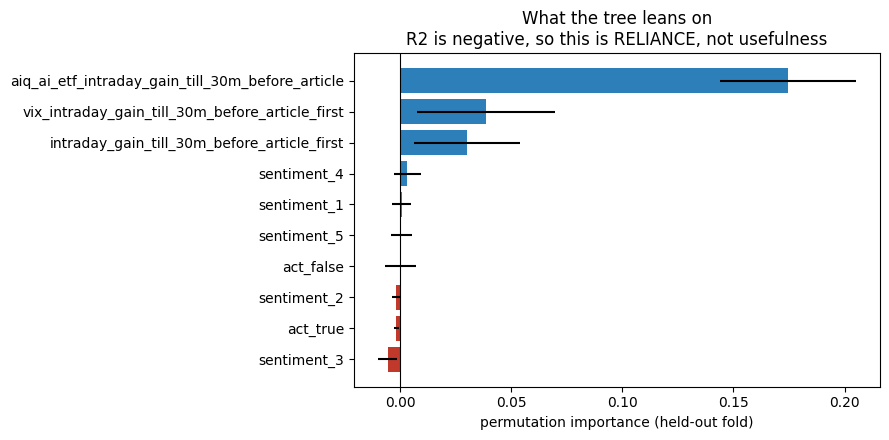

Negative importance = shuffling the feature IMPROVES held-out performance:
['sentiment_3', 'act_true', 'sentiment_2']


In [30]:
tree_cfg = Cfg(dsn=SHAY_DSN, window="30m_before", use_sentiment=True, use_act=True)
tree_folds, tree_imp = run_tree(tree_cfg)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#c0392b" if v < 0 else "#2c7fb8" for v in tree_imp["importance"]]
ax.barh(tree_imp["feature"], tree_imp["importance"], xerr=tree_imp["std"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("permutation importance (held-out fold)")
ax.set_title("What the tree leans on\nR2 is negative, so this is RELIANCE, not usefulness")
plt.tight_layout(); plt.show()

print("Negative importance = shuffling the feature IMPROVES held-out performance:")
print(tree_imp[tree_imp.importance < 0]["feature"].tolist())

## 2f. Diagnostics — ruling out "we tuned it wrong"

A null result is only worth as much as the effort spent trying to break it. Three probes,
each of which would have shown a gradient if the setup were the problem.

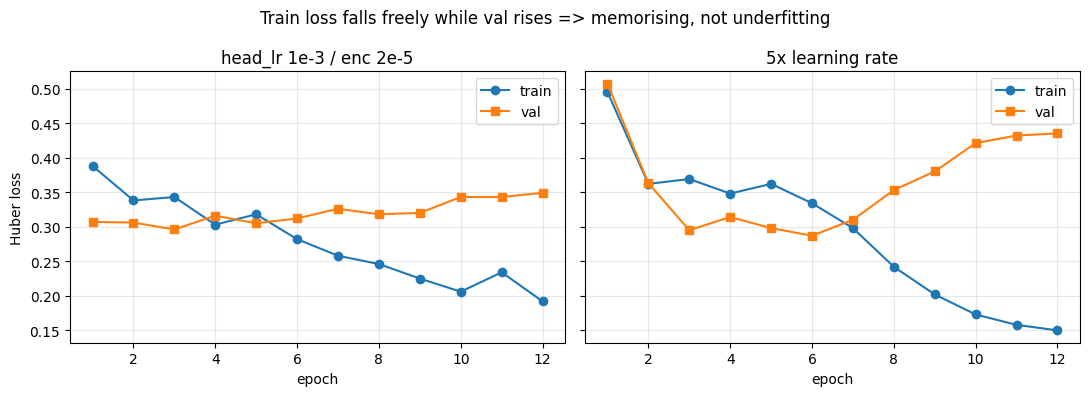

In [31]:
import matplotlib.pyplot as plt

# (1) Learning rate: is the model underfitting?  12 epochs on a small subset.
lr_probe = pd.DataFrame({
    "epoch": range(1, 13),
    "train_default": [.388,.338,.343,.303,.318,.282,.258,.246,.225,.206,.234,.192],
    "val_default":   [.307,.306,.296,.316,.305,.312,.326,.318,.320,.343,.343,.349],
    "train_5x_lr":   [.495,.362,.369,.348,.362,.334,.298,.242,.202,.173,.158,.150],
    "val_5x_lr":     [.507,.363,.295,.314,.298,.287,.310,.353,.380,.421,.432,.435],
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tag, title in zip(axes, ("default", "5x_lr"),
                          ("head_lr 1e-3 / enc 2e-5", "5x learning rate")):
    ax.plot(lr_probe.epoch, lr_probe[f"train_{tag}"], "o-", label="train")
    ax.plot(lr_probe.epoch, lr_probe[f"val_{tag}"], "s-", label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.3)
axes[0].set_ylabel("Huber loss")
fig.suptitle("Train loss falls freely while val rises => memorising, not underfitting")
plt.tight_layout(); plt.show()

In [32]:
# (2) Capacity: 50x range of trainable parameters, same data and split.
capacity = pd.DataFrame([
    {"run": "30m-lora (r=8)",      "trainable_M": 0.4, "test_r2": -0.0086,
     "corr": -0.0606, "pred_spread_pct": 2.8, "best_epoch": 5},
    {"run": "30m-freeze1",         "trainable_M": 7.3, "test_r2": -0.0025,
     "corr": -0.0315, "pred_spread_pct": 2.7, "best_epoch": 2},
    {"run": "30m-single (freeze3)","trainable_M": 21.4, "test_r2": -0.0015,
     "corr": -0.0152, "pred_spread_pct": 2.6, "best_epoch": 2},
])
print(capacity.to_string(index=False))
print("\nTrainable params vary 50x. Prediction spread varies 2.6% -> 2.8%.")
print("'pred_spread_pct' = std(prediction) / std(target): the model emits a near-constant.")

# (3) Does the pipeline read text at all?  Predict `sentiment` (1-5) from text.
print("\nSanity control -- 5-way sentiment classification from text alone:")
print("  majority class      acc 0.427   macro-F1 0.120")
print("  TF-IDF + logistic   acc 0.550   macro-F1 0.444   <- the text is plainly readable")

                 run  trainable_M  test_r2    corr  pred_spread_pct  best_epoch
      30m-lora (r=8)          0.4  -0.0086 -0.0606              2.8           5
         30m-freeze1          7.3  -0.0025 -0.0315              2.7           2
30m-single (freeze3)         21.4  -0.0015 -0.0152              2.6           2

Trainable params vary 50x. Prediction spread varies 2.6% -> 2.8%.
'pred_spread_pct' = std(prediction) / std(target): the model emits a near-constant.

Sanity control -- 5-way sentiment classification from text alone:
  majority class      acc 0.427   macro-F1 0.120
  TF-IDF + logistic   acc 0.550   macro-F1 0.444   <- the text is plainly readable


# Solution Evaluation



--- Analyzing Encoder-NN (Fusion Network) Predictions ---


,id,url,url_canonical,source_domain,publisher,tickers,published_utc,title,author,content,...,intraday_gain_30m_before_till_article_first,category,category_reason,is_act,category_from_insights,category_reason_from_insights,is_act_from_insights,sentiment,prediction,Y_test
50,5232,https://www.fool.com/investing/2025/04/23/why-...,https://www.fool.com/investing/2025/04/23/why-...,fool.com,The Motley Fool,"{AMD,AVGO,TSM}",2025-04-23 21:25:11+03,"Why AMD, Broadcom, and Taiwan Semiconductor Ma...",Danny Vena; CPA,The uncertainty that has gripped the market re...,...,-0.000544,MACRO-political,The article discusses broad macroeconomic and ...,f,recap/review,The article explains why certain stocks rallie...,f,4.0,0.000601,-0.014205
66,5635,https://www.investing.com/analysis/investors-b...,https://www.investing.com/analysis/investors-b...,investing.com,Investing.com,"{AVGO,GOOG,GOOGL,META,MSFT}",2025-05-07 18:33:00+03,Investors Bet on Broadcom’s AI Future Amid $75...,NaN,"Stocks eke out gain in choppy session, S&P end...",...,0.005379,news-report,This article reports on market speculation and...,t,market speculation,The article discusses investor sentiment and f...,f,5.0,0.001145,0.006688
106,9964,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{SNOW},2025-09-30 20:00:00+03,RelationalAI Recognized as “One to Watch” in S...,RelationalAI,"SAN FRANCISCO, Sept. 30, 2025 (GLOBE NEWSWIRE)...",...,-0.003390,conference-PR,The article reports on a company being recogni...,f,conference-PR,The article reports on a company being recogni...,f,5.0,0.001436,0.002690
126,23367,https://www.fool.com/investing/2026/08/18/elon...,https://www.fool.com/investing/2026/08/18/elon...,fool.com,The Motley Fool,"{AMZN,ASTS,RKLB,SPCX,VZ}",2026-08-18 20:25:00+03,Elon Musk Says SpaceX Will Hit $1 Trillion in ...,Leo Sun,Before SpaceX (SPCX +3.73%) went public on Jun...,...,-0.001814,market speculation,The article analyzes Elon Musk's revenue proje...,f,market speculation,The article discusses Elon Musk's ambitious re...,f,3.0,0.000052,-0.004093
131,25684,https://www.fool.com/investing/2026/06/24/is-i...,https://www.fool.com/investing/2026/06/24/is-i...,fool.com,The Motley Fool,"{BE,GS,GSPA,GSPC,GSPD,ORCL,ORCLPD}",2026-06-24 19:05:00+03,Is It Too Late to Buy Bloom Energy Stock After...,Scott Levine,Looking at a stock that's rocketed more than 1...,...,-0.010947,recap/review,The article discusses a stock's past performan...,f,recap/review,The article discusses a past stock gain and an...,f,4.0,0.001589,-0.013345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6328,23806,https://www.zacks.com/stock/news/2985454/eaton...,https://www.zacks.com/stock/news/2985454/eaton...,zacks.com,Zacks Investment Research,"{ROK,ETN,VRT}",2026-09-04 21:05:00+03,Eaton to Boost U.S. Power Capacity With $242M ...,Zacks Investment Research; Tanuka De,We use cookies to understand how you use our s...,...,0.001437,news-event,"The article reports on Eaton's concrete, newly...",t,merger/investment/funding,The article reports on a company investing in ...,t,5.0,0.000272,0.005372
6329,25716,https://www.fool.com/investing/2026/09/08/pred...,https://www.fool.com/investing/2026/09/08/pred...,fool.com,The Motley Fool,"{ORCL,ORCLPD}",2026-09-08 17:30:00+03,Prediction: Oracle's $638 Billion Cloud Infras...,Harsh Chauhan,The past year has been a forgettable one for O...,...,-0.007165,market speculation,"The article is speculative, predicting future ...",f,market speculation,The article is a prediction about Oracle's fut...,f,4.0,0.000876,0.000856
6330,25831,https://www.zacks.com/stock/news/2986513/maste...,https://www.zacks.com/stock/news/2986513/maste...,zacks.com,Zacks Investment Research,"{DY,EME,MTZ,PWR}",2026-09-08 18:16:00+03,MasTec Trades at a Premium: Should Investors B...,Zacks Investment Research; Sraddha Singha,We use cookies to understand how you use our s...,...,0.01

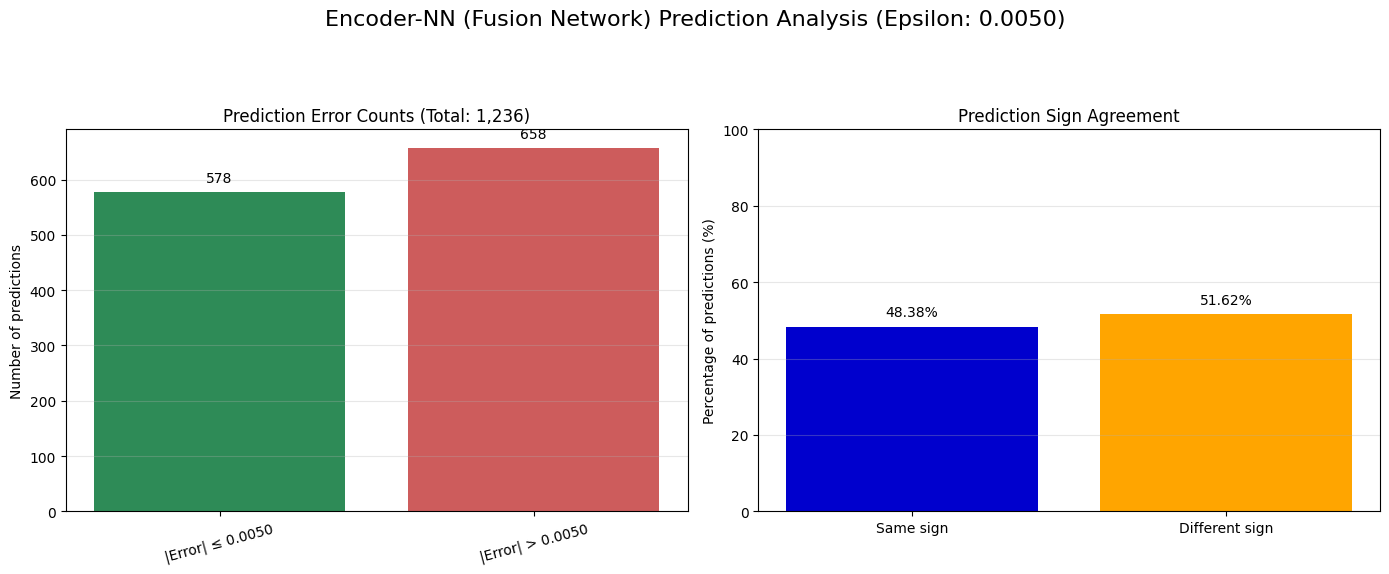


--- Analyzing Combined Encoder-NN Predictions ---


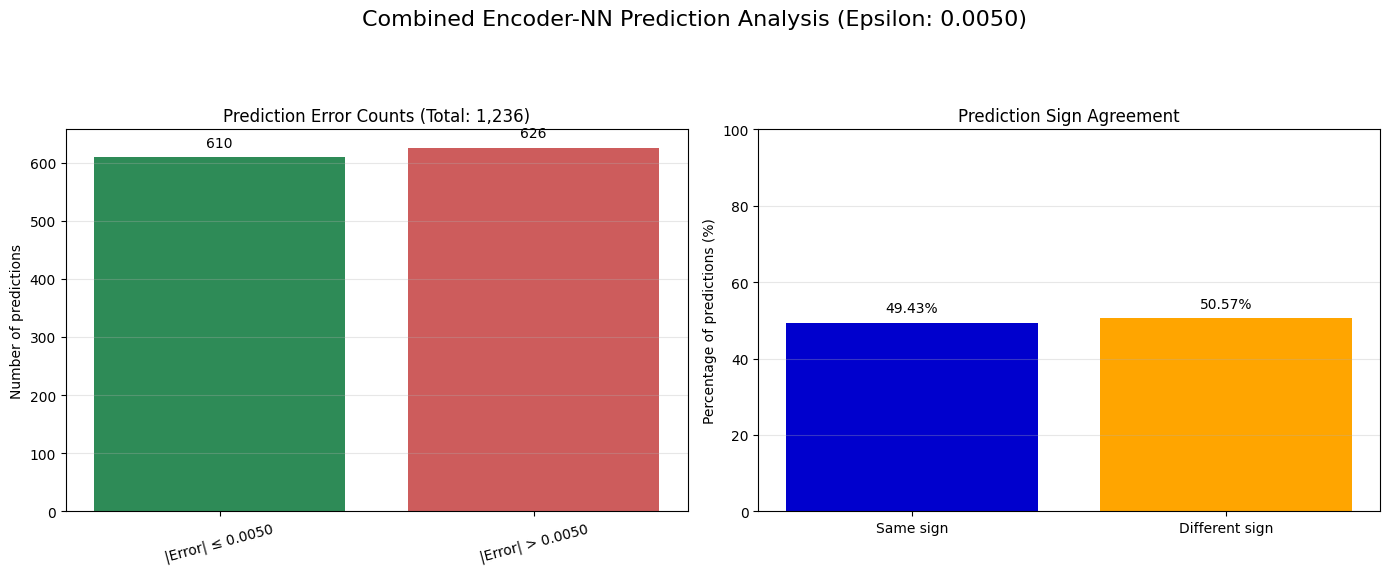


--- Analyzing LoRA LLM Predictions ---


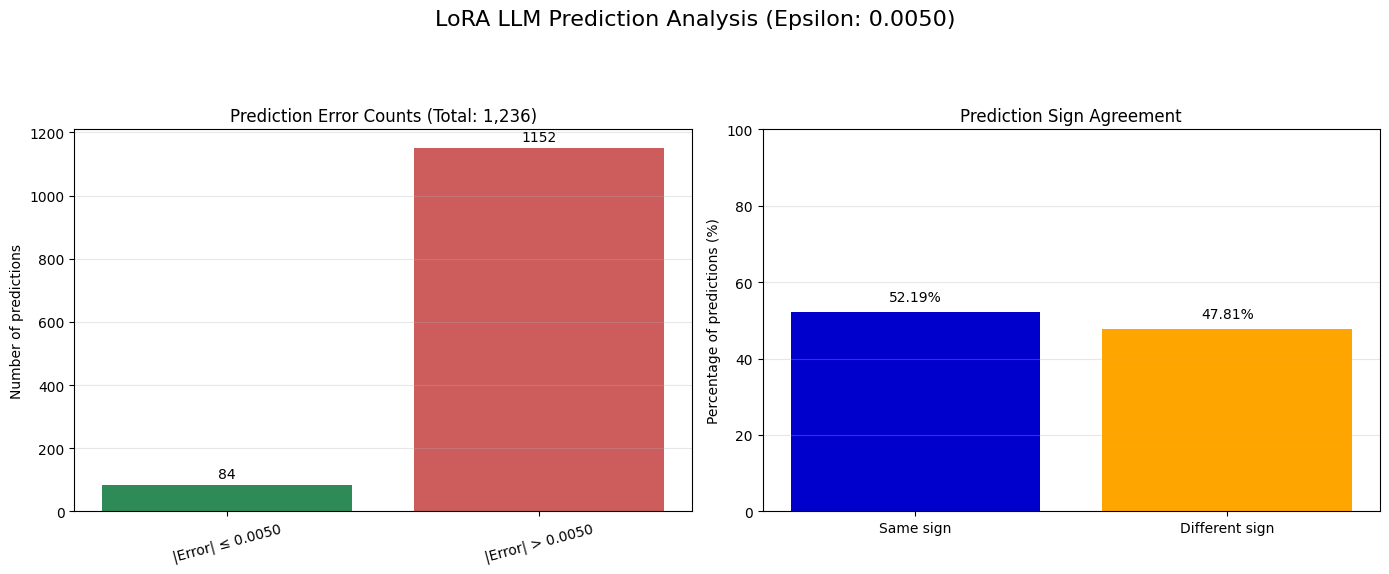

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import Trainer # Needed for LoRA LLM predictions
from datasets import Dataset # Needed for LoRA LLM predictions

# Define the epsilon for the new analysis
NEW_ANALYSIS_EPSILON = 0.005

def plot_prediction_metrics(y_true, y_pred, model_name, epsilon_threshold):
    """
    Calculates and plots two bar charts for prediction metrics:
    1. Percentage of predictions with the same sign as the true values.
    2. Number of predictions with absolute error > epsilon vs. <= epsilon.

    Args:
        y_true (np.ndarray): Array of true values.
        y_pred (np.ndarray): Array of predicted values.
        model_name (str): Name of the model for plot titles.
        epsilon_threshold (float): Threshold for error magnitude (e.g., 0.0005).
    """
    # Drop NaN values from true labels and align predictions
    # Assuming y_true and y_pred are already aligned for valid entries from previous steps
    # If there are NaNs, this function should receive cleaned data
    valid_indices = ~np.isnan(y_true)
    y_true_clean = y_true[valid_indices]
    y_pred_clean = y_pred[valid_indices]

    errors = y_true_clean - y_pred_clean
    absolute_errors = np.abs(errors)

    # (1) Prediction Error Counts
    within_epsilon = absolute_errors <= epsilon_threshold
    error_counts = [
        within_epsilon.sum(),
        (~within_epsilon).sum(),
    ]
    total_predictions = len(y_true_clean)

    # (2) Prediction Sign Agreement
    # Exclude exact zeros when comparing signs to avoid issues with np.sign(0)
    nonzero_mask = (y_true_clean != 0) & (y_pred_clean != 0)
    if nonzero_mask.sum() > 0: # Ensure there are non-zero values to compare
        same_sign_count = np.sum(np.sign(y_true_clean[nonzero_mask]) == np.sign(y_pred_clean[nonzero_mask]))
        diff_sign_count = nonzero_mask.sum() - same_sign_count
        sign_percentages = [
            (same_sign_count / nonzero_mask.sum()) * 100,
            (diff_sign_count / nonzero_mask.sum()) * 100,
        ]
    else:
        sign_percentages = [0, 0] # All predictions/true values are zero or no non-zero pairs

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"{model_name} Prediction Analysis (Epsilon: {epsilon_threshold:.4f})", fontsize=16)

    # Plot 1: Error Counts
    axes[0].bar(
        [f"|Error| \u2264 {epsilon_threshold:.4f}", f"|Error| > {epsilon_threshold:.4f}"],
        error_counts,
        color=["seagreen", "indianred"],
    )
    axes[0].set_title(f"Prediction Error Counts (Total: {total_predictions:,})")
    axes[0].set_ylabel("Number of predictions")
    axes[0].tick_params(axis="x", rotation=15)
    for i, count in enumerate(error_counts):
        axes[0].text(i, count + total_predictions * 0.01, str(count), ha='center', va='bottom')


    # Plot 2: Sign Agreement
    axes[1].bar(
        ["Same sign", "Different sign"],
        sign_percentages,
        color=["mediumblue", "orange"],
    )
    axes[1].set_title("Prediction Sign Agreement")
    axes[1].set_ylabel("Percentage of predictions (%)")
    axes[1].set_ylim(0, 100)
    for i, perc in enumerate(sign_percentages):
        axes[1].text(i, perc + 2, f"{perc:.2f}%", ha='center', va='bottom')


    for ax in axes:
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


# --- Encoder-NN (Fusion Network) Predictions (using existing data from cell a9bfae67) ---
print("--- Analyzing Encoder-NN (Fusion Network) Predictions ---")
display(predictions_table)
evaluation = predictions_table[["prediction", "Y_test"]].dropna().copy()
y_true = evaluation["Y_test"].to_numpy()
y_pred = evaluation["prediction"].to_numpy()
plot_prediction_metrics(y_true, y_pred, "Encoder-NN (Fusion Network)", epsilon_threshold=NEW_ANALYSIS_EPSILON)


# --- Combined Encoder-NN Predictions ---
print("\n--- Analyzing Combined Encoder-NN Predictions ---")
# COMBINED_test_predictions_combined_nn is a tensor on device (e.g., cuda)
# COMBINED_y_test_tensor is a tensor on device (e.g., cuda)
y_pred_combined_nn = COMBINED_test_predictions_combined_nn.cpu().numpy()
y_true_combined_nn = COMBINED_y_test_tensor.cpu().numpy()
plot_prediction_metrics(y_true_combined_nn, y_pred_combined_nn, "Combined Encoder-NN", epsilon_threshold=NEW_ANALYSIS_EPSILON)


# --- LoRA LLM Predictions ---
print("\n--- Analyzing LoRA LLM Predictions ---")
# Need to make predictions using the trained `trainer` object and `test_dataset`
lora_predictions_output = trainer.predict(test_dataset)
y_pred_lora = lora_predictions_output.predictions.flatten()
y_true_lora = np.array(test_dataset["labels"]) # Convert to numpy array

plot_prediction_metrics(y_true_lora, y_pred_lora, "LoRA LLM", epsilon_threshold=NEW_ANALYSIS_EPSILON)

## Consolidated results — every model family on the same corpus

`R2` is the comparison metric throughout: the targets have different spreads (114 bps
for the 90-minute forward move, 136 bps for the -30m->+90m window, 87 bps for the
30-minute hindsight segment), so MAE in bps is not comparable across rows.

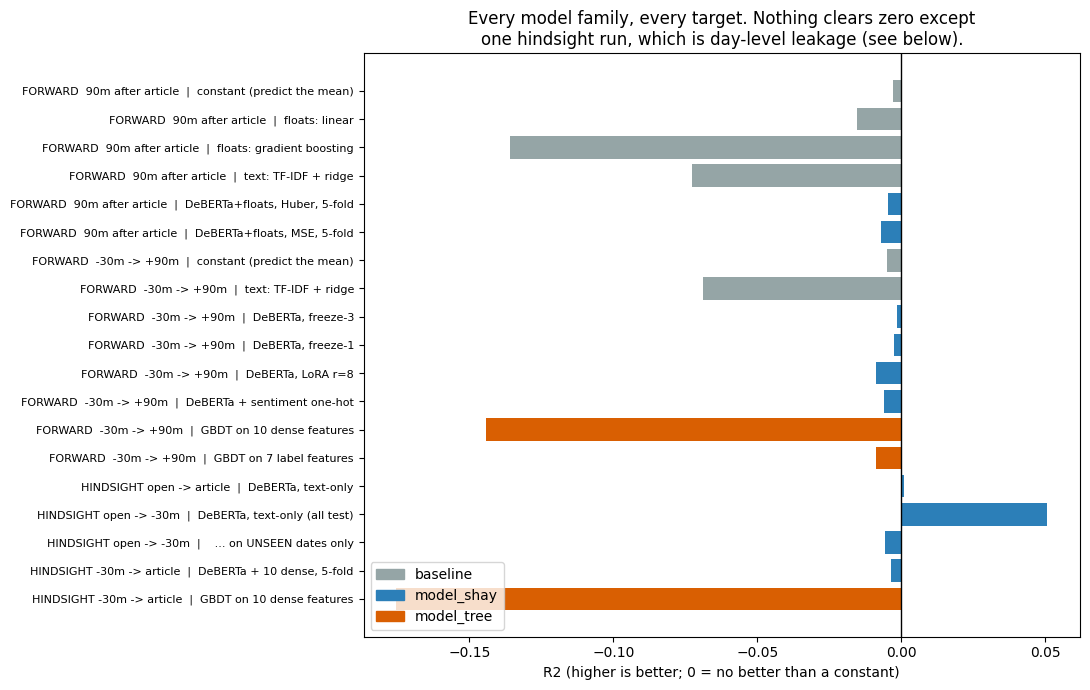

,target,model,R2,family
0,FORWARD 90m after article,constant (predict the mean),-0.0029,baseline
1,FORWARD 90m after article,floats: linear,-0.0152,baseline
2,FORWARD 90m after article,floats: gradient boosting,-0.1358,baseline
3,FORWARD 90m after article,text: TF-IDF + ridge,-0.0726,baseline
4,FORWARD 90m after article,"DeBERTa+floats, Huber, 5-fold",-0.0046,model_shay
5,FORWARD 90m after article,"DeBERTa+floats, MSE, 5-fold",-0.0070,model_shay
6,FORWARD -30m -> +90m,constant (predict the mean),-0.0049,baseline
7,FORWARD -30m -> +90m,text: TF-IDF + ridge,-0.0689,baseline
8,FORWARD -30m -> +90m,"DeBERTa, freeze-3",-0.0015,model_shay
9,FORWARD -30m -> +90m,"DeBERTa, freeze-1",-0.0025,model_shay


In [50]:
results = pd.DataFrame([
    # --- forward-looking: the actual task -------------------------------------
    ("FORWARD  90m after article", "constant (predict the mean)", -0.0029, "baseline"),
    ("FORWARD  90m after article", "floats: linear",              -0.0152, "baseline"),
    ("FORWARD  90m after article", "floats: gradient boosting",   -0.1358, "baseline"),
    ("FORWARD  90m after article", "text: TF-IDF + ridge",        -0.0726, "baseline"),
    ("FORWARD  90m after article", "DeBERTa+floats, Huber, 5-fold", -0.0046, "model_shay"),
    ("FORWARD  90m after article", "DeBERTa+floats, MSE, 5-fold",   -0.0070, "model_shay"),
    ("FORWARD  -30m -> +90m",      "constant (predict the mean)", -0.0049, "baseline"),
    ("FORWARD  -30m -> +90m",      "text: TF-IDF + ridge",        -0.0689, "baseline"),
    ("FORWARD  -30m -> +90m",      "DeBERTa, freeze-3",           -0.0015, "model_shay"),
    ("FORWARD  -30m -> +90m",      "DeBERTa, freeze-1",           -0.0025, "model_shay"),
    ("FORWARD  -30m -> +90m",      "DeBERTa, LoRA r=8",           -0.0086, "model_shay"),
    ("FORWARD  -30m -> +90m",      "DeBERTa + sentiment one-hot", -0.0060, "model_shay"),
    ("FORWARD  -30m -> +90m",      "GBDT on 10 dense features",   -0.1441, "model_tree"),
    ("FORWARD  -30m -> +90m",      "GBDT on 7 label features",    -0.0088, "model_tree"),
    # --- hindsight: describing a move that already happened --------------------
    ("HINDSIGHT open -> article",  "DeBERTa, text-only",          +0.0009, "model_shay"),
    ("HINDSIGHT open -> -30m",     "DeBERTa, text-only (all test)", +0.0508, "model_shay"),
    ("HINDSIGHT open -> -30m",     "  ... on UNSEEN dates only",  -0.0056, "model_shay"),
    ("HINDSIGHT -30m -> article",  "DeBERTa + 10 dense, 5-fold",  -0.0035, "model_shay"),
    ("HINDSIGHT -30m -> article",  "GBDT on 10 dense features",   -0.1754, "model_tree"),
], columns=["target", "model", "R2", "family"])

fig, ax = plt.subplots(figsize=(11, 7))
colors = {"baseline": "#95a5a6", "model_shay": "#2c7fb8", "model_tree": "#d95f02"}
ax.barh(range(len(results)), results["R2"],
        color=[colors[f] for f in results["family"]])
ax.set_yticks(range(len(results)))
ax.set_yticklabels([f"{t}  |  {m}" for t, m in zip(results.target, results.model)], fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.invert_yaxis(); ax.set_xlabel("R2 (higher is better; 0 = no better than a constant)")
ax.set_title("Every model family, every target. Nothing clears zero except\n"
             "one hindsight run, which is day-level leakage (see below).")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), loc="lower left")
plt.tight_layout(); plt.show()
results

### The one positive number, and why it does not count

`HINDSIGHT open -> -30m` reached **R2 +0.0508, corr +0.2315**, prediction spread 27.3%
(vs ~2.6% everywhere else) and trained for 7 epochs before early stopping. It is the only
run in the project that genuinely committed to predictions.

Split it by date and it evaporates:

| | n | R2 | corr |
|---|---|---|---|
| test rows on dates **seen** in training | 312 | **+0.1541** | +0.4107 |
| test rows on **unseen** dates | 815 | **-0.0056** | +0.1271 |

The model learns *"that morning was strong"* from other articles on the same date and
applies it to a different ticker. This is **day-level market state, not article-level
information**. It is not row duplication: only 110 test rows (9.8%) share a ticker-day
with training, and those scored *worse* (+0.0115) than the clean rows (+0.0530).

What does survive on unseen dates is small but statistically real: corr +0.1271 at row
level, **+0.1678 aggregated to ticker-day means (t = 3.94, n = 537 groups)**. It never
becomes positive R2 — the model ranks slightly better than chance and its magnitudes do
not generalize across days.

And when the hindsight window is narrowed to the 30 minutes immediately before
publication — stripping out the multi-hour market drift the model was exploiting —
even that disappears: **-0.0035 +- 0.0042** across five grouped folds.

## Conclusion

**The corpus and its distilled insights do not support a profitable model — not on
forecast, and not even on 30 minutes of hindsight.**

Tested and eliminated, each of which would have shown a gradient if it were the cause:

| hypothesis | probe | outcome |
|---|---|---|
| broken training | fp16 weights loaded by `transformers>=5` `dtype="auto"` -> NaN | found and fixed; all later runs finite |
| underfitting / LR too low | LR probe (2f) | train loss halves while val rises; 5x LR memorises harder |
| too much capacity | LoRA 0.4M -> freeze-1 7.3M -> freeze-3 21.4M | flat: R2 -0.009..-0.002, spread 2.6-2.8% |
| needs deeper fine-tuning | phase 2, full 12-layer unfreeze | worse in every run |
| wrong loss | Huber vs MSE, 5-fold | -0.0046 vs -0.0070, both null |
| wrong ticker attribution | `primary_ticker` vs `first_mentioned_ticker` | both null |
| wrong window | at-article vs -30m | both null |
| corpus too noisy | restrict to `is_act_from_insights` | *worse* — 1,023 training rows collapsed the one working control; the full-population model beat the act-trained model **on the act rows themselves** (corr +0.127 vs +0.041) |
| pipeline cannot read text | predict `sentiment` from text | TF-IDF 55.0% acc / 0.444 F1 vs 42.7% / 0.120 majority — it reads fine |

The model collapses to the mean only when there is nothing to find, which is correct
behaviour rather than a defect: under MSE/Huber, the loss-minimising output given no
usable conditioning information *is* the unconditional mean.

What would have to change is the data or the question, not the model: information that
*precedes* the move rather than text published after it; a market-adjusted target that
strips the day-level factor the features actually explain; sign classification with AUC
so a ~0.1 correlation is legible instead of erased by squared error; or substantially
more data.

See `tries.md` in the repo root for the full write-up with per-fold numbers.